# OHLC Conditional — CSV-based Analysis

Loads pre-generated samples from CSV files produced by `generate_samples.py`
and compares the generated Close paths against ground-truth Close.

No model inference is performed here — just load, parse, and analyse.

Expected CSVs (under `<GEN_DIR>/<CHECKPOINT_STEM>/`):
- `train_generated_close.csv` — generated Close paths for training windows
- `train_gt_ohlc.csv`         — ground-truth OHLC context for training windows
- `val_generated_close.csv`   — generated Close paths for validation windows
- `val_gt_ohlc.csv`           — ground-truth OHLC context for validation windows

CSV schemas
-----------
`*_generated_close.csv`: `window_idx | sample_idx | file | window_start | step_000 … step_{L-1}`

`*_gt_ohlc.csv`: `window_idx | feature | file | window_start | step_000 … step_{L-1}`

In [1]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
CHECKPOINT_STEM = (
    "csv20000_samples5_steps200_seed50_20260604_233534_UNCO_Pm-1.4_Ps1.8"
)

folder_prefix = "../../Master-Thesis"  # base path to be prepended to all other paths below
GEN_DIR = f"{folder_prefix}/data/generated/final/edm"

SPLIT = "val"   # "train" | "val" | "both"

is_unconditional = True   # True for unconditional checkpoints (single GT feature, no OHL context)

appendix = "repl_UNCO_both_Ps18_smax_PROVA"
# ─────────────────────────────────────────────────────────────────────────────


In [2]:
# ── USER INPUTS ── unnormalization ────────────────────────────────────────────
STATS_FILE      = f"{folder_prefix}/data/general/normalization_stats_norm_replication.csv"   # path to mean/std CSV
RAW_DATA_FOLDER = f"{folder_prefix}/data/SNP500_individual"        # folder of per-ticker CSVs
# ─────────────────────────────────────────────────────────────────────────────


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf

ckpt_dir = os.path.join(GEN_DIR, CHECKPOINT_STEM)
assert os.path.isdir(ckpt_dir), f"Directory not found: {ckpt_dir}"
print(f"Reading from: {ckpt_dir}")

Reading from: ../../Master-Thesis/data/generated/final/edm\csv20000_samples5_steps200_seed50_20260604_233534_UNCO_Pm-1.4_Ps1.8


## 1. Load CSVs

In [4]:
def load_split(split, ckpt_dir):
    """
    Load one split's generated-close and GT-OHLC CSVs.

    Returns
    -------
    df_gen  : DataFrame  (window_idx, sample_idx, file, window_start, step_*)
    df_ohlc : DataFrame  (window_idx, feature, file, window_start, step_*)
    step_cols : list of step column names
    """
    gen_path  = os.path.join(ckpt_dir, f"{split}_generated_close.csv")
    ohlc_path = os.path.join(ckpt_dir, f"{split}_gt_ohlc.csv")

    assert os.path.isfile(gen_path),  f"Not found: {gen_path}"
    assert os.path.isfile(ohlc_path), f"Not found: {ohlc_path}"

    df_gen  = pd.read_csv(gen_path)
    df_ohlc = pd.read_csv(ohlc_path)

    step_cols = [c for c in df_gen.columns if c.startswith("step_")]
    seq_len   = len(step_cols)

    n_windows = df_gen["window_idx"].nunique()
    n_samples = df_gen["sample_idx"].nunique()
    features  = df_ohlc["feature"].unique().tolist()

    print(f"[{split}] windows={n_windows}  samples/window={n_samples}  "
          f"seq_len={seq_len}  features={features}")

    return df_gen, df_ohlc, step_cols


splits_to_run = ["train", "val"] if SPLIT == "both" else [SPLIT]
data = {}

for split in splits_to_run:
    try:
        df_gen, df_ohlc, step_cols = load_split(split, ckpt_dir)
        data[split] = (df_gen, df_ohlc, step_cols)
    except AssertionError as e:
        print(f"Skipping {split}: {e}")

[val] windows=237  samples/window=5  seq_len=512  features=['close']


## 2. Parse into NumPy arrays

Reshape DataFrames into `(n_windows, n_samples, seq_len)` for generated Close
and `(n_windows, seq_len)` per OHLC feature for ground-truth context.

In [5]:
def parse_arrays(df_gen, df_ohlc, step_cols):
    """
    Returns
    -------
    gen_3d     : (n_windows, n_samples, seq_len)
    gt_close   : (n_windows, seq_len)
    gt_open    : (n_windows, seq_len) or None   ← None when is_unconditional
    gt_high    : (n_windows, seq_len) or None
    gt_low     : (n_windows, seq_len) or None
    window_ids : list[int]
    """
    window_ids = sorted(df_gen["window_idx"].unique())
    n_windows  = len(window_ids)
    n_samples  = df_gen["sample_idx"].nunique()
    seq_len    = len(step_cols)

    gen_3d = np.zeros((n_windows, n_samples, seq_len), dtype=np.float32)
    for wi, wid in enumerate(window_ids):
        sub = df_gen[df_gen["window_idx"] == wid].sort_values("sample_idx")
        gen_3d[wi] = sub[step_cols].to_numpy(dtype=np.float32)

    def gt_feat(feat_name):
        sub = df_ohlc[df_ohlc["feature"] == feat_name].sort_values("window_idx")
        return sub[step_cols].to_numpy(dtype=np.float32)   # (n_windows, seq_len)

    if is_unconditional:
        sole_feat = df_ohlc["feature"].unique()[0]   # e.g. "log_adj_close"
        gt_close  = gt_feat(sole_feat)
        gt_open = gt_high = gt_low = None
    else:
        gt_open  = gt_feat("open")
        gt_high  = gt_feat("high")
        gt_low   = gt_feat("low")
        gt_close = gt_feat("close")

    return gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids


parsed = {}
for split, (df_gen, df_ohlc, step_cols) in data.items():
    parsed[split] = parse_arrays(df_gen, df_ohlc, step_cols)
    gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids = parsed[split]
    print(f"[{split}] gen_3d={gen_3d.shape}  gt_close={gt_close.shape}")


[val] gen_3d=(237, 5, 512)  gt_close=(237, 512)


---
## Analyses

The cells below run on the **first available split** by default.  
Change `ANALYSIS_SPLIT` to switch between `"train"` / `"val"`.

In [6]:
ANALYSIS_SPLIT = splits_to_run[0]

gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids = parsed[ANALYSIS_SPLIT]
n_windows, n_samples, seq_len = gen_3d.shape
steps = np.arange(seq_len)

all_gen_close = gen_3d.reshape(n_windows * n_samples, seq_len)
all_gt_close  = np.repeat(gt_close, n_samples, axis=0)
all_gt_high   = np.repeat(gt_high, n_samples, axis=0) if not is_unconditional else None
all_gt_low    = np.repeat(gt_low,  n_samples, axis=0) if not is_unconditional else None

print(f"Split         : {ANALYSIS_SPLIT}")
print(f"n_windows     : {n_windows}")
print(f"n_samples     : {n_samples}")
print(f"seq_len       : {seq_len}")
print(f"all_gen_close : {all_gen_close.shape}")


Split         : val
n_windows     : 237
n_samples     : 5
seq_len       : 512
all_gen_close : (1185, 512)


## 3. Sample path overlays

For each shown window: ground-truth OHL band + GT Close (top row) vs
GT OHL band + all generated Close samples (bottom row).

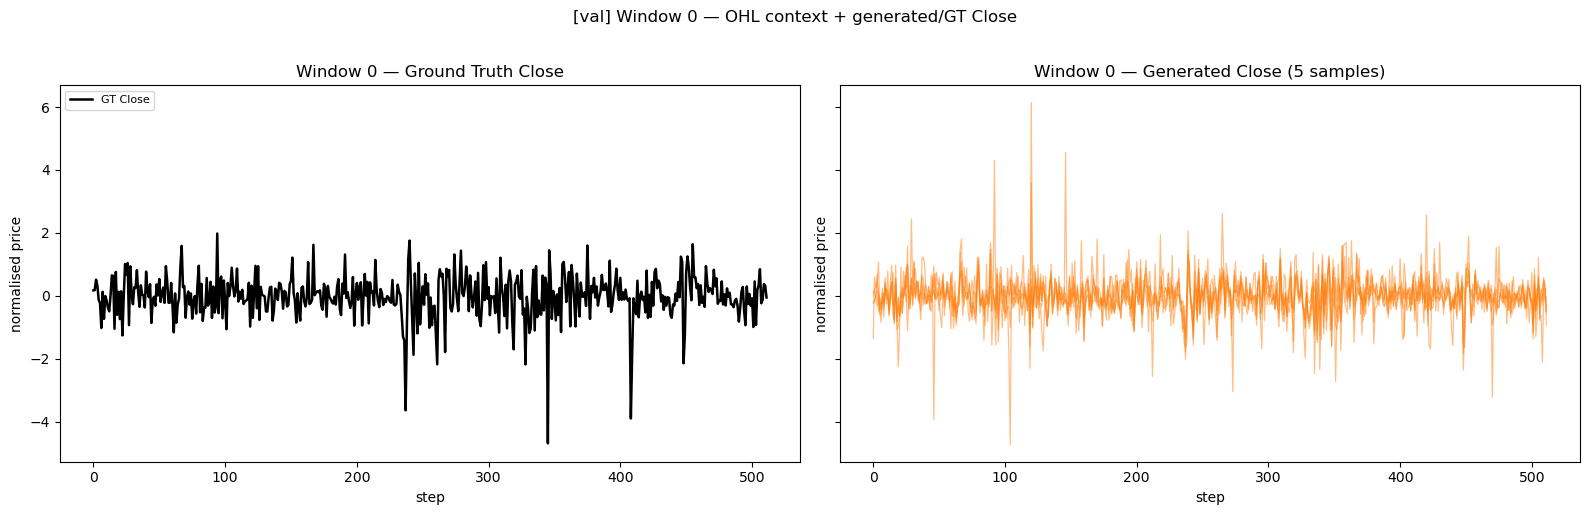

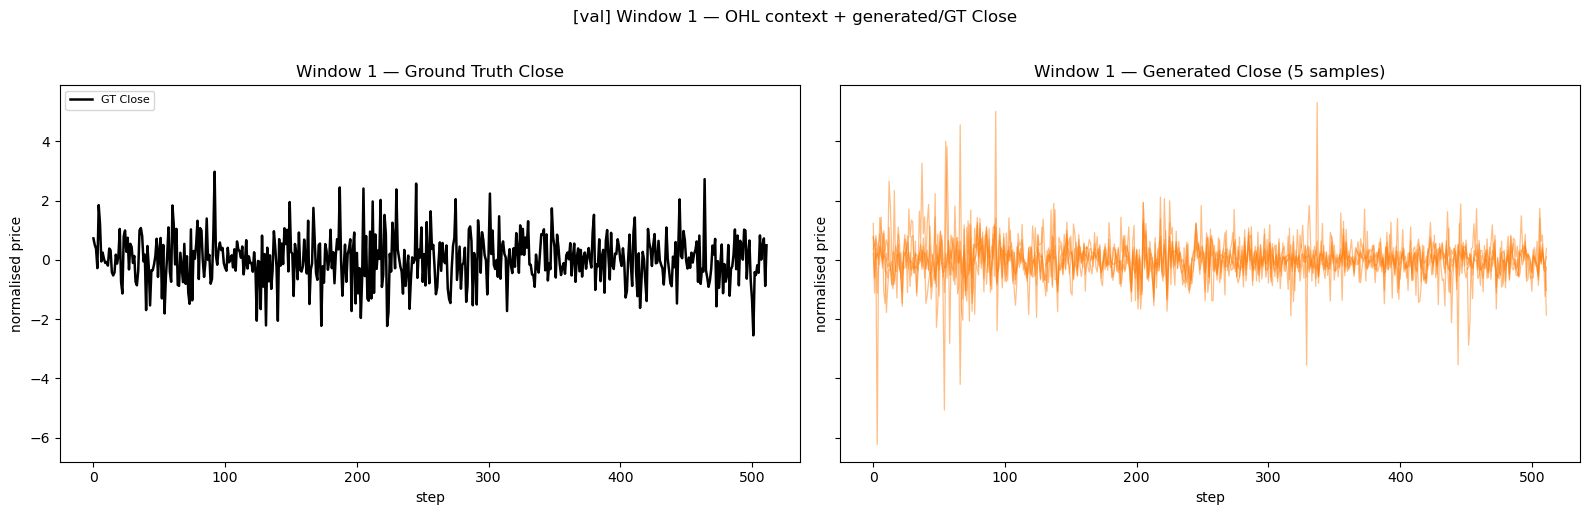

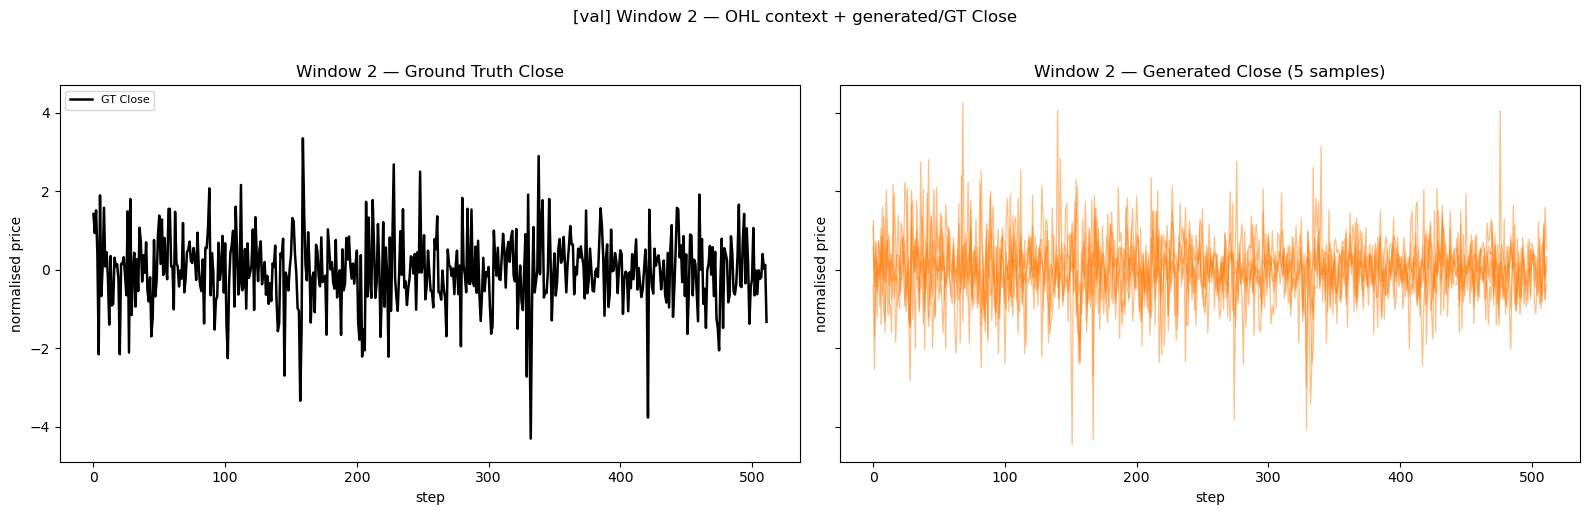

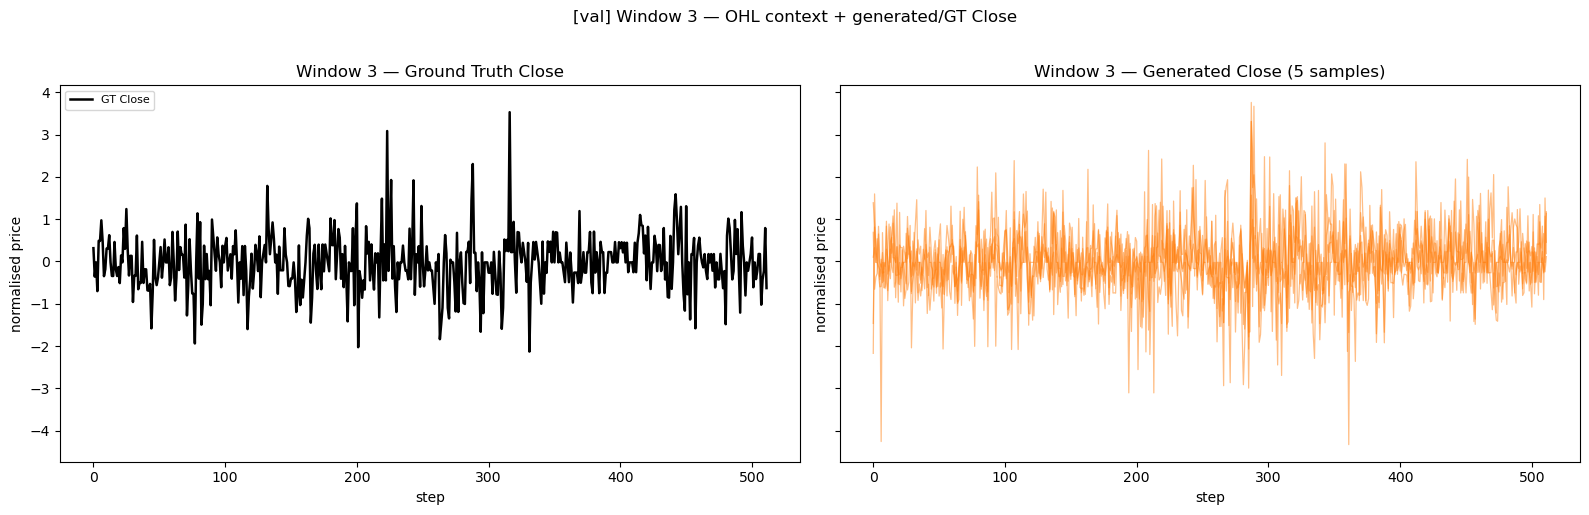

In [7]:
N_SHOW = min(n_windows, 4)

for w in range(N_SHOW):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    if not is_unconditional:
        for ax in axes:
            ax.fill_between(steps, gt_low[w], gt_high[w],
                            alpha=0.15, color="gray", label="[L, H] band")
            ax.plot(steps, gt_open[w], color="steelblue", lw=1.0, ls="--", alpha=0.7, label="Open")
            ax.plot(steps, gt_high[w], color="green",     lw=1.0, ls="--", alpha=0.7, label="High")
            ax.plot(steps, gt_low[w],  color="red",       lw=1.0, ls="--", alpha=0.7, label="Low")
    for ax in axes:
        ax.set_xlabel("step")
        ax.set_ylabel("normalised price")

    axes[0].plot(steps, gt_close[w], color="black", lw=1.8, label="GT Close")
    axes[0].set_title(f"Window {window_ids[w]} — Ground Truth Close")
    axes[0].legend(fontsize=8, loc="upper left")

    for s in range(n_samples):
        axes[1].plot(steps, gen_3d[w, s], color="tab:orange", lw=0.9, alpha=0.5)
    axes[1].set_title(f"Window {window_ids[w]} — Generated Close ({n_samples} samples)")

    plt.suptitle(
        f"[{ANALYSIS_SPLIT}] Window {window_ids[w]} — OHL context + generated/GT Close",
        y=1.02, fontsize=12
    )
    plt.tight_layout()
    plt.show()


## 4. OHLC constraint satisfaction

Checks whether the generated Close satisfies `L ≤ Close ≤ H`.

> Note: data are normalised column-wise, so this constraint can be broken locally even for perfectly generated samples — treat the rate as a diagnostic, not an absolute criterion.

In [8]:
if is_unconditional:
    print("OHLC constraint check skipped — no OHL context in unconditional mode.")
else:
    above_low  = all_gen_close >= all_gt_low
    below_high = all_gen_close <= all_gt_high
    in_band    = above_low & below_high

    step_rate   = in_band.mean(axis=0)
    fully_valid = in_band.all(axis=1).mean()
    stepwise    = in_band.mean()

    gt_above_low  = all_gt_close >= all_gt_low
    gt_below_high = all_gt_close <= all_gt_high
    gt_in_band    = gt_above_low & gt_below_high

    gt_step_rate   = gt_in_band.mean(axis=0)
    gt_fully_valid = gt_in_band.all(axis=1).mean()
    gt_stepwise    = gt_in_band.mean()

    print("=" * 55)
    print("  OHLC CONSTRAINT  L ≤ Close ≤ H")
    print("=" * 55)
    print(f"{'Metric':<35} {'Generated':>10} {'GT (ref)':>10}")
    print("-" * 55)
    print(f"{'Step-wise satisfaction rate':<35} {stepwise:>10.4f} {gt_stepwise:>10.4f}")
    print(f"{'Fully valid samples':<35} {fully_valid:>10.4f} {gt_fully_valid:>10.4f}")

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(steps, step_rate,    color="tab:orange", lw=1.5, label=f"Generated  (overall={stepwise:.3f})")
    ax.plot(steps, gt_step_rate, color="tab:blue",   lw=1.5, label=f"GT (ref)   (overall={gt_stepwise:.3f})", ls="--")
    ax.axhline(1.0, color="black", lw=0.8, ls=":", label="Perfect (1.0)")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("step t")
    ax.set_ylabel("fraction in [L, H]")
    ax.set_title(f"[{ANALYSIS_SPLIT}] OHLC constraint per step — Generated vs GT")
    ax.legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)


OHLC constraint check skipped — no OHL context in unconditional mode.


## 5. Marginal distribution of Close values
We are testing:
* Marginal close distribution overall
* QQ plots for quantile values
* ECDF (Empirical CDF), or F(x)=(y<=x) / N, where y is the number of values smaller or equal to x and N is the total number of observations.

KS statistic = 0.0330  |  p-value = 8.4113e-288
Wasserstein-1 distance = 0.097116
Exact zeros — Generated: 0.0000%  |  GT: 0.0000%


,mean,std,min,q01,q05,q25,q50,q75,q95,q99,max,skewness,excess_kurtosis
label,,,,,,,,,,,,,
Generated Close,0.00306,0.73136,-32.091202,-1.95946,-1.08682,-0.35183,-0.02139,0.35364,1.11312,2.02323,14.240830,-0.35577,19.90179
Ground-truth Close,0.00617,0.99073,-35.273560,-2.42867,-1.30806,-0.40798,-0.02163,0.41600,1.33233,2.45924,107.896858,20.61117,2342.13456


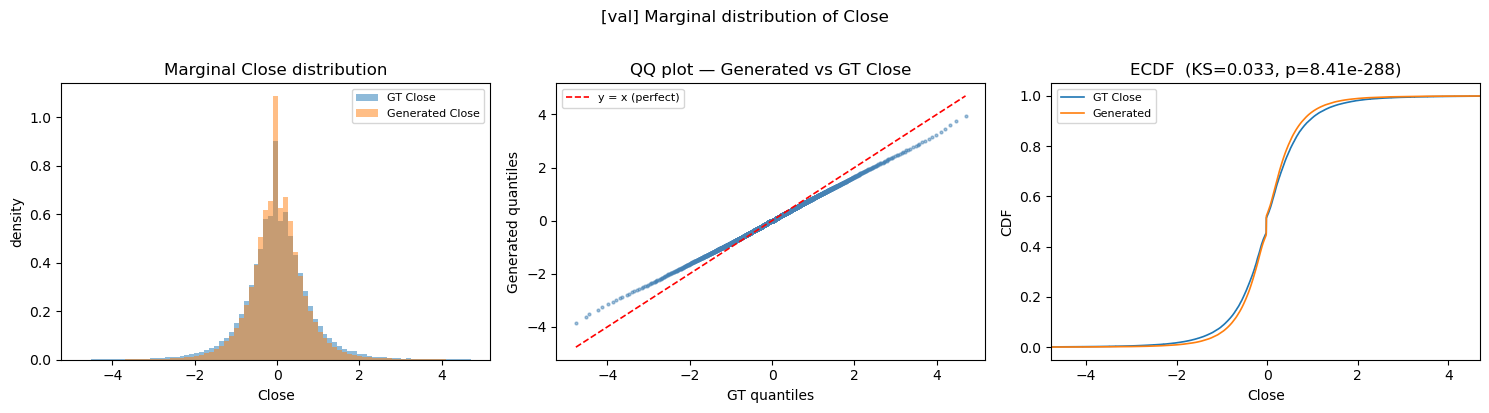

In [9]:
gen_flat = all_gen_close.ravel()
gt_flat  = all_gt_close.ravel()

ks_stat, ks_p = scipy_stats.ks_2samp(gen_flat, gt_flat)
w1_dist = scipy_stats.wasserstein_distance(gen_flat, gt_flat)


def moments(x, label):
    return {
        "label"           : label,
        "mean"            : np.mean(x),
        "std"             : np.std(x),
        "min"             : np.min(x),
        "q01"             : np.quantile(x, 0.01),
        "q05"             : np.quantile(x, 0.05),
        "q25"             : np.quantile(x, 0.25),
        "q50"             : np.quantile(x, 0.50),
        "q75"             : np.quantile(x, 0.75),
        "q95"             : np.quantile(x, 0.95),
        "q99"             : np.quantile(x, 0.99),
        "max"             : np.max(x),
        "skewness"        : scipy_stats.skew(x),
        "excess_kurtosis" : scipy_stats.kurtosis(x, fisher=True),
    }

df_moments = pd.DataFrame([
    moments(gen_flat, "Generated Close"),
    moments(gt_flat,  "Ground-truth Close"),
]).set_index("label").round(5)

print(f"KS statistic = {ks_stat:.4f}  |  p-value = {ks_p:.4e}")
print(f"Wasserstein-1 distance = {w1_dist:.6f}")

pct_zero_gen = 100 * np.mean(gen_flat == 0)
pct_zero_gt  = 100 * np.mean(gt_flat  == 0)
print(f"Exact zeros — Generated: {pct_zero_gen:.4f}%  |  GT: {pct_zero_gt:.4f}%")


display(df_moments)

combined = np.concatenate([gen_flat, gt_flat])
lo, hi   = np.quantile(gt_flat, [0.001, 0.999])
bins     = np.linspace(lo, hi, 80)
probs    = np.linspace(0.001, 0.999, min(len(gen_flat), 5_000))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(gt_flat,  bins=bins, density=True, alpha=0.5, label="GT Close",        color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.5, label="Generated Close", color="tab:orange")
ax.set_title("Marginal Close distribution")
ax.set_xlabel("Close"); ax.set_ylabel("density"); ax.legend(fontsize=8)

ax = axes[1]
q_gt  = np.quantile(gt_flat,  probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_gt, q_gen, s=4, alpha=0.5, color="steelblue")
lims = [min(q_gt.min(), q_gen.min()), max(q_gt.max(), q_gen.max())]
ax.plot(lims, lims, "r--", lw=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — Generated vs GT Close")
ax.set_xlabel("GT quantiles"); ax.set_ylabel("Generated quantiles"); ax.legend(fontsize=8)

ax = axes[2]
for vals, label, color in [(gt_flat, "GT Close", "tab:blue"), (gen_flat, "Generated", "tab:orange")]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, lw=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF  (KS={ks_stat:.3f}, p={ks_p:.2e})")
ax.set_xlabel("Close"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Marginal distribution of Close", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"{folder_prefix}/images/final/edm/comparison/marginal_distribution_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

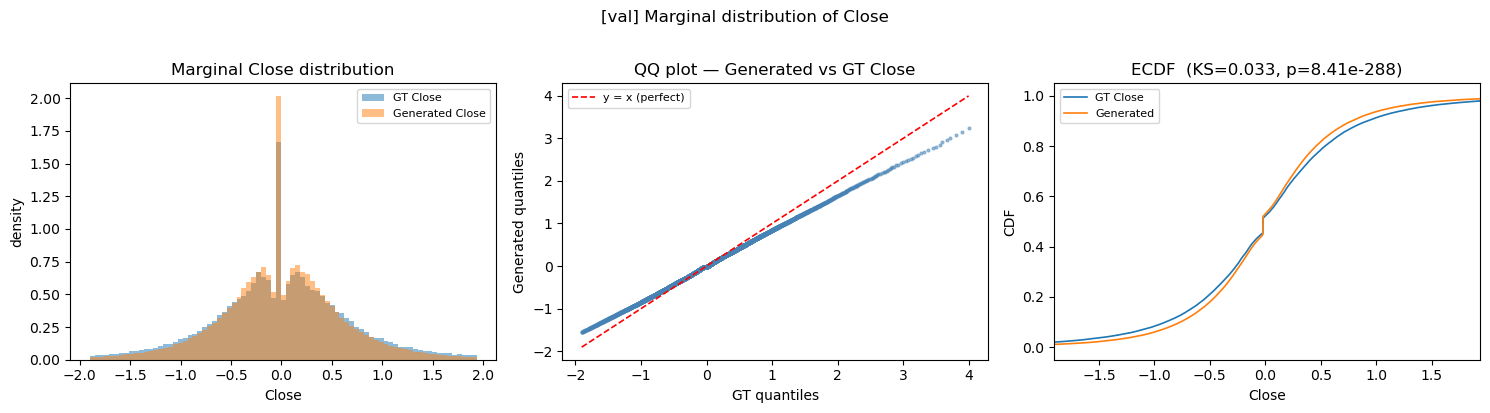

In [10]:
# TRIMMED
combined = np.concatenate([gen_flat, gt_flat])
lo, hi   = np.quantile(gt_flat, [0.02, 0.98])
bins     = np.linspace(lo, hi, 80)
probs    = np.linspace(0.02, 0.998, min(len(gen_flat), 5_000))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(gt_flat,  bins=bins, density=True, alpha=0.5, label="GT Close",        color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.5, label="Generated Close", color="tab:orange")
ax.set_title("Marginal Close distribution")
ax.set_xlabel("Close"); ax.set_ylabel("density"); ax.legend(fontsize=8)

ax = axes[1]
q_gt  = np.quantile(gt_flat,  probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_gt, q_gen, s=4, alpha=0.5, color="steelblue")
lims = [min(q_gt.min(), q_gen.min()), max(q_gt.max(), q_gen.max())]
ax.plot(lims, lims, "r--", lw=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — Generated vs GT Close")
ax.set_xlabel("GT quantiles"); ax.set_ylabel("Generated quantiles"); ax.legend(fontsize=8)

ax = axes[2]
for vals, label, color in [(gt_flat, "GT Close", "tab:blue"), (gen_flat, "Generated", "tab:orange")]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, lw=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF  (KS={ks_stat:.3f}, p={ks_p:.2e})")
ax.set_xlabel("Close"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Marginal distribution of Close", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"{folder_prefix}/images/final/edm/comparison/mar_distr_THINNER_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

In [11]:
# KS on the central 98 % (exclude bottom/top 1 % of the combined distribution)
combined_q01, combined_q99 = np.quantile(np.concatenate([gen_flat, gt_flat]), [0.01, 0.99])
gen_trim = gen_flat[(gen_flat >= combined_q01) & (gen_flat <= combined_q99)]
gt_trim  = gt_flat [(gt_flat  >= combined_q01) & (gt_flat  <= combined_q99)]
ks_trim_stat, ks_trim_p = scipy_stats.ks_2samp(data1 = gen_trim, data2 = gt_trim, method = "asymp", alternative="two-sided")
print(f"KS statistic (trimmed, central 98%) = {ks_trim_stat:.4f}  |  p-value = {ks_trim_p:.4e}")


KS statistic (trimmed, central 98%) = 0.0323  |  p-value = 1.7346e-270


## 6. Close increments distribution and ACF

Increment KS = 0.0298  p = 9.0331e-235
Wasserstein-1 distance (subsampled) = 0.132590


,mean,std,min,q01,q05,q25,q50,q75,q95,q99,max,skewness,excess_kurtosis
label,,,,,,,,,,,,,
Generated ΔClose,0.00009,1.03577,-31.70825,-2.78804,-1.57270,-0.52531,-0.00003,0.52131,1.57742,2.81605,33.060032,0.07281,12.14026
GT ΔClose,0.00003,1.40218,-108.12236,-3.41020,-1.86164,-0.60470,-0.00143,0.59391,1.87936,3.49692,107.918266,0.08748,1176.20228


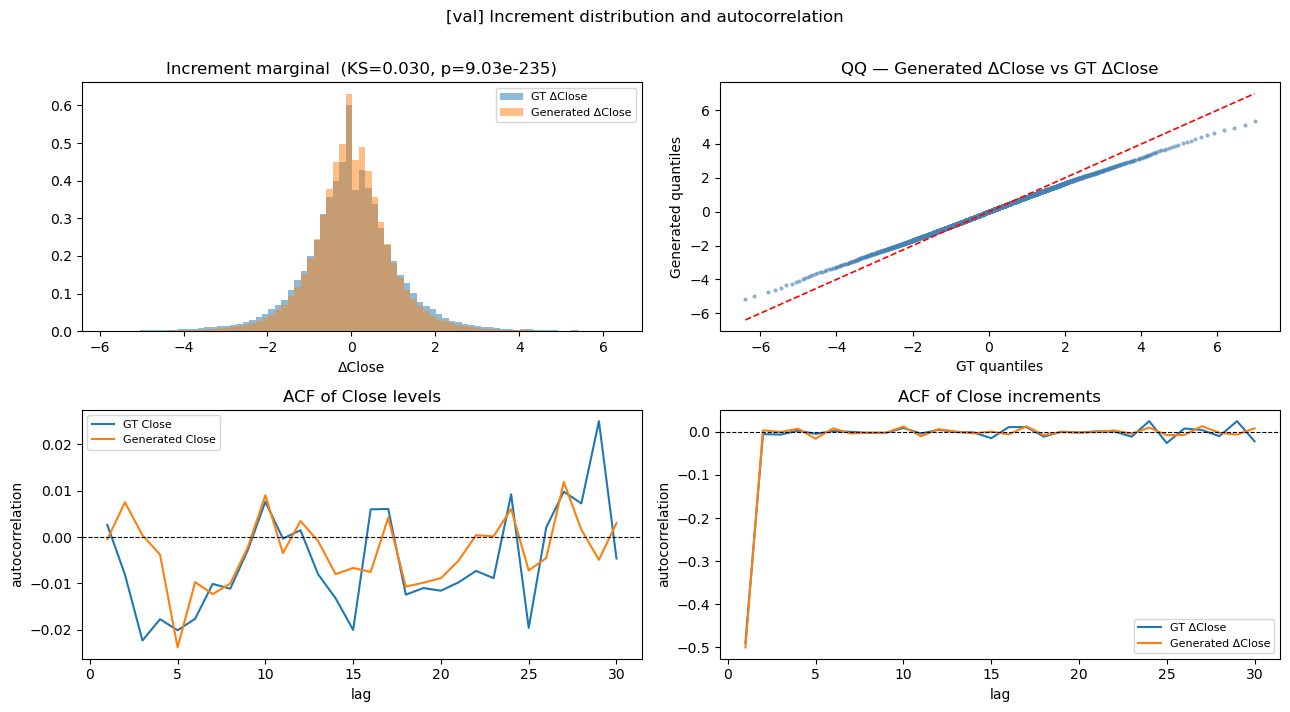

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Lenovo\\Documents\\SCUOLA\\UNI\\MASTER\\2ANNO\\THESIS\\Master-Thesis-edm_validation\\images\\final\\edm\\comparison\\marginal_distribution_repl_UNCO_both_Ps18_smax_PROVA.png'

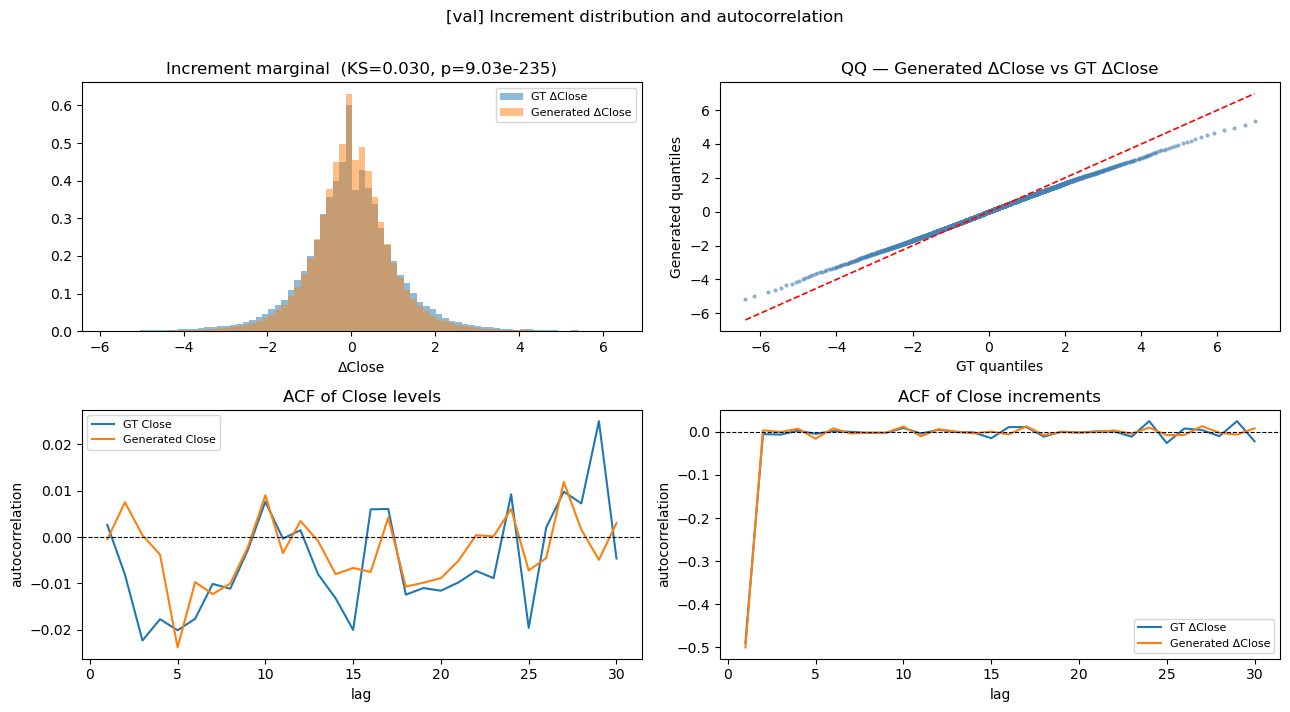

In [12]:
gen_inc = np.diff(all_gen_close, axis=1).ravel()
gt_inc  = np.diff(all_gt_close,  axis=1).ravel()

ks_inc, ks_p_inc = scipy_stats.ks_2samp(gen_inc, gt_inc)
print(f"Increment KS = {ks_inc:.4f}  p = {ks_p_inc:.4e}")

MAX_W1 = 10_000_000
rng = np.random.default_rng(0)
idx_gen = rng.choice(len(gen_inc), size=min(MAX_W1, len(gen_inc)), replace=False)
idx_gt  = rng.choice(len(gt_inc),  size=min(MAX_W1, len(gt_inc)),  replace=False)

w1_dist_inc = scipy_stats.wasserstein_distance(gen_inc[idx_gen], gt_inc[idx_gt])
print(f"Wasserstein-1 distance (subsampled) = {w1_dist_inc:.6f}")




df_inc = pd.DataFrame([
    moments(gen_inc, "Generated ΔClose"),
    moments(gt_inc,  "GT ΔClose"),
]).set_index("label").round(5)
display(df_inc)

N_ACF    = min(50, n_windows)
LAGS     = min(30, seq_len // 2)
lag_axis = np.arange(1, LAGS + 1)

def mean_acf(paths, lags, use_diff=False):
    acfs = []
    for p in paths[:N_ACF]:
        x = np.diff(p) if use_diff else p
        acfs.append(acf(x, nlags=lags, fft=True)[1:])
    return np.mean(acfs, axis=0)

# For ACF we pick one sample per window (sample 0) to avoid repetition artefacts
gen_paths_s0 = gen_3d[:, 0, :]   # (n_windows, seq_len)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

lo_i, hi_i = np.quantile(np.concatenate([gen_inc, gt_inc]), [0.001, 0.999])
bins_i = np.linspace(lo_i, hi_i, 80)
axes[0, 0].hist(gt_inc,  bins=bins_i, density=True, alpha=0.5, label="GT ΔClose",        color="tab:blue")
axes[0, 0].hist(gen_inc, bins=bins_i, density=True, alpha=0.5, label="Generated ΔClose", color="tab:orange")
axes[0, 0].set_title(f"Increment marginal  (KS={ks_inc:.3f}, p={ks_p_inc:.2e})")
axes[0, 0].set_xlabel("ΔClose"); axes[0, 0].legend(fontsize=8)

probs_i = np.linspace(0.001, 0.999, min(len(gen_inc), 5_000))
q_gt_i  = np.quantile(gt_inc,  probs_i)
q_gen_i = np.quantile(gen_inc, probs_i)
axes[0, 1].scatter(q_gt_i, q_gen_i, s=4, alpha=0.5, color="steelblue")
lims_i = [min(q_gt_i.min(), q_gen_i.min()), max(q_gt_i.max(), q_gen_i.max())]
axes[0, 1].plot(lims_i, lims_i, "r--", lw=1.2)
axes[0, 1].set_title("QQ — Generated ΔClose vs GT ΔClose")
axes[0, 1].set_xlabel("GT quantiles"); axes[0, 1].set_ylabel("Generated quantiles")

axes[1, 0].plot(lag_axis, mean_acf(gt_close,      LAGS, use_diff=False), label="GT Close",        color="tab:blue")
axes[1, 0].plot(lag_axis, mean_acf(gen_paths_s0,  LAGS, use_diff=False), label="Generated Close", color="tab:orange")
axes[1, 0].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 0].set_title("ACF of Close levels")
axes[1, 0].set_xlabel("lag"); axes[1, 0].set_ylabel("autocorrelation"); axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(lag_axis, mean_acf(gt_close,      LAGS, use_diff=True), label="GT ΔClose",        color="tab:blue")
axes[1, 1].plot(lag_axis, mean_acf(gen_paths_s0,  LAGS, use_diff=True), label="Generated ΔClose", color="tab:orange")
axes[1, 1].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 1].set_title("ACF of Close increments")
axes[1, 1].set_xlabel("lag"); axes[1, 1].set_ylabel("autocorrelation"); axes[1, 1].legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Increment distribution and autocorrelation", y=1.01)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/comparison/marginal_distribution_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

## 7. Per-step conditional mean ± std

At each timestep: generated sample mean vs GT Close, with ±1 std band.

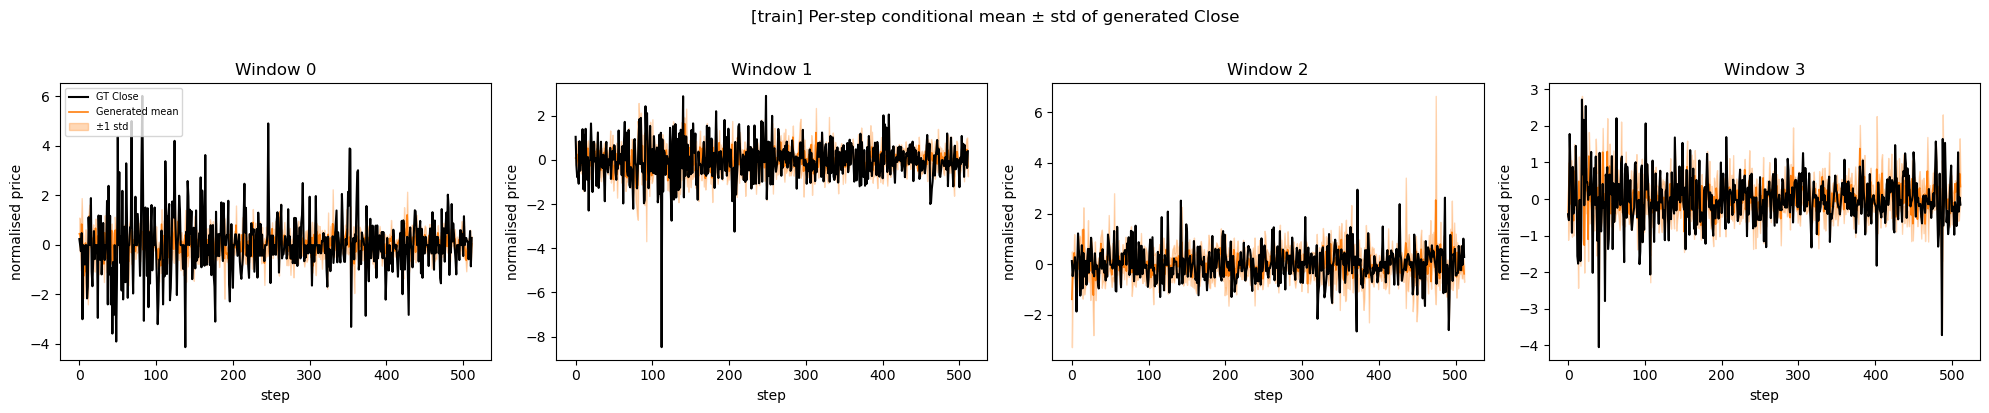

Mean absolute error  (generated mean vs GT): 0.61784
RMSE                 (generated mean vs GT): 0.95348
Mean generated std   (residual uncertainty): 0.50544


In [ ]:
gen_mean = gen_3d.mean(axis=1)
gen_std  = gen_3d.std(axis=1)

N_SHOW2 = min(n_windows, 4)
fig, axes = plt.subplots(1, N_SHOW2, figsize=(5 * N_SHOW2, 4), sharey=False)
if N_SHOW2 == 1:
    axes = [axes]

for col, w in enumerate(range(N_SHOW2)):
    ax = axes[col]
    ax.plot(steps, gt_close[w],  color="black",      lw=1.5, label="GT Close",       zorder=3)
    ax.plot(steps, gen_mean[w],  color="tab:orange", lw=1.2, label="Generated mean", zorder=2)
    ax.fill_between(
        steps,
        gen_mean[w] - gen_std[w],
        gen_mean[w] + gen_std[w],
        alpha=0.3, color="tab:orange", label="±1 std"
    )
    if not is_unconditional:
        ax.fill_between(steps, gt_low[w], gt_high[w], alpha=0.10, color="gray", label="[L, H]")
    ax.set_title(f"Window {window_ids[w]}")
    ax.set_xlabel("step")
    ax.set_ylabel("normalised price")

axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle(f"[{ANALYSIS_SPLIT}] Per-step conditional mean ± std of generated Close", y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

mae  = np.abs(gen_mean - gt_close).mean()
rmse = np.sqrt(((gen_mean - gt_close) ** 2).mean())
print(f"Mean absolute error  (generated mean vs GT): {mae:.5f}")
print(f"RMSE                 (generated mean vs GT): {rmse:.5f}")
print(f"Mean generated std   (residual uncertainty): {gen_std.mean():.5f}")


## 8. Train vs Val comparison (requires SPLIT="both")

Side-by-side summary statistics for train and validation splits.

In [ ]:
if len(parsed) < 2:
    print("Set SPLIT='both' at the top to enable train/val comparison.")
else:
    rows = []
    for sp, (g3d, gtc, gto, gth, gtl, wids) in parsed.items():
        nw, ns, sl = g3d.shape
        gen_all = g3d.reshape(nw * ns, sl)
        gt_all  = np.repeat(gtc, ns, axis=0)
        ks, ks_p  = scipy_stats.ks_2samp(gen_all.ravel(), gt_all.ravel())
        gm = g3d.mean(axis=1)
        mae  = np.abs(gm - gtc).mean()
        rmse = np.sqrt(((gm - gtc) ** 2).mean())
        if gtl is not None and gth is not None:
            in_b = ((gen_all >= np.repeat(gtl, ns, axis=0)) &
                    (gen_all <= np.repeat(gth, ns, axis=0))).mean()
        else:
            in_b = float("nan")
        rows.append({
            "split"          : sp,
            "n_windows"      : nw,
            "n_samples"      : ns,
            "KS stat"        : round(ks, 4),
            "KS p-value"     : f"{ks_p:.2e}",
            "MAE (mean vs GT)": round(mae, 5),
            "RMSE"           : round(rmse, 5),
            "OHLC step rate" : round(float(in_b), 4),
        })
    display(pd.DataFrame(rows).set_index("split"))

,n_windows,n_samples,KS stat,KS p-value,MAE (mean vs GT),RMSE,OHLC step rate
split,,,,,,,
train,20000,5,0.042,0.00e+00,0.61784,0.95348,NaN
val,237,5,0.033,8.41e-288,0.56622,0.94384,NaN


# 9. FTS metrics

In [13]:
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../../Master-Thesis")
import replication.stylized_facts as sf
from pathlib import Path

output_dir = Path("../images/final/edm/stylized_facts_ohlc_conditional")
output_dir.mkdir(exist_ok=True, parents=True)
print(f"Saving stylized facts plots to: {output_dir.resolve()}")


Saving stylized facts plots to: C:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\THESIS\Master-Thesis-edm_validation\images\final\edm\stylized_facts_ohlc_conditional


In [14]:
MAX_STEM_LEN = 40
if len(CHECKPOINT_STEM) > MAX_STEM_LEN:
    CHECKPOINT_STEM = CHECKPOINT_STEM[:MAX_STEM_LEN] + CHECKPOINT_STEM[-14:]
print(CHECKPOINT_STEM)

csv20000_samples5_steps200_seed50_202606O_Pm-1.4_Ps1.8


In [15]:
print(gt_close.shape, gt_close.shape[0]*gt_close.shape[1])
print(all_gen_close.shape, all_gen_close.shape[0]*all_gen_close.shape[1])

(237, 512) 121344
(1185, 512) 606720


In [16]:
# ── Flat 1-D arrays for sf.distribution ──────────────────────────────────────
# gt_close  : (n_windows, seq_len) → ravel to 1-D
# all_gen_close : (n_windows * n_samples, seq_len) — already defined above
gt_close_pooled = gt_close.ravel()        # shape: (n_windows * seq_len,)
gen_paths_arr   = all_gen_close.ravel()   # shape: (n_windows * n_samples * seq_len,)

print(gt_close_pooled.shape)
print(gen_paths_arr.shape)

# ── Object arrays of individual paths for sf.acf / sf.leverage_effect ────────
gt_close_obj = np.empty(n_windows, dtype=object)
for i, p in enumerate(gt_close):
    gt_close_obj[i] = p                   # each element: (seq_len,) GT Close window

gen_paths_obj = np.empty(len(all_gen_close), dtype=object)
for i, p in enumerate(all_gen_close):
    gen_paths_obj[i] = p                  # each element: (seq_len,) generated path

print(gt_close_obj.shape, gt_close_obj[0].shape)
print(gen_paths_obj.shape, gen_paths_obj[0].shape)

(121344,)
(606720,)
(237,) (512,)
(1185,) (512,)


In [17]:
compute_graph_overlap = True

In [ ]:
gt_dist_x, gt_dist_y = sf.distribution(
    gt_close_pooled,
    file_name=str(output_dir / f"gt_distribution_{CHECKPOINT_STEM}_{appendix}"),
    scale="log", multiple=False, normalize=True, granuality=100,
)

gen_dist_x, gen_dist_y = sf.distribution(
    gen_paths_arr,
    file_name=str(output_dir / f"generated_distribution_{CHECKPOINT_STEM}_{appendix}"),
    scale="log", multiple=False, normalize=True, granuality=100,
)


In [ ]:
# subsample generated paths to match reference size (or any fixed N)
subsample = True
if subsample:
    rng = np.random.default_rng(42)
    n_sub = int(len(gt_close_obj) * 0.5)
    idx_gen = rng.choice(len(gen_paths_obj), size=n_sub, replace=False)
    idx_ref = rng.choice(len(gt_close_obj), size=n_sub, replace=False)
    gen_paths_obj_sub = gen_paths_obj[idx_gen]
    ref_paths_obj_sub = gt_close_obj[idx_ref]


In [ ]:
if not subsample:
    gt_acf_res = sf.acf(
        gt_close_obj,
        file_name=str(output_dir / f"gt_volatility_clustering_{CHECKPOINT_STEM}_{appendix}"),
        for_abs=True, multiple=True, fit=False, scale="log",
        max_lag=min(1000, seq_len // 2),
    )

    gen_acf_res = sf.acf(
        gen_paths_obj,
        file_name=str(output_dir / f"generated_volatility_clustering_{CHECKPOINT_STEM}_{appendix}"),
        for_abs=True, multiple=True, fit=False, scale="log",
        max_lag=min(1000, seq_len // 2),
    )
else:
    gt_acf_res = sf.acf(
        ref_paths_obj_sub,
        file_name=str(output_dir / f"gt_vol_clust_SUBSAMPLED_{CHECKPOINT_STEM}_{appendix}"),
        for_abs=True, multiple=True, fit=False, scale="log",
        max_lag=min(1000, seq_len // 2),
    )

    gen_acf_res = sf.acf(
        gen_paths_obj_sub,
        file_name=str(output_dir / f"gen_vol_clust_SUBSAMPLED_{CHECKPOINT_STEM}_{appendix}"),
        for_abs=True, multiple=True, fit=False, scale="log",
        max_lag=min(1000, seq_len // 2),
    )

c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
gt_levs = sf.leverage_effect(
    gt_close_obj,
    file_name=str(output_dir / f"gt_leverage_effect_{CHECKPOINT_STEM}_{appendix}"),
    multiple=True, min_lag=1, max_lag=min(100, seq_len // 2),
)

gen_levs = sf.leverage_effect(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_leverage_effect_{CHECKPOINT_STEM}_{appendix}"),
    multiple=True, min_lag=1, max_lag=min(100, seq_len // 2),
)


NameError: name 'sf' is not defined

In [ ]:
# import powerlaw

run_fast_powerlaw = True
# if not run_fast_powerlaw:
#     def fit_powerlaw(returns, max_sample=10000, seed=42):
#         x = np.abs(np.asarray(returns, dtype=float))
#         x = x[np.isfinite(x) & (x > 0)]

#         if len(x) > max_sample:
#             rng_local = np.random.default_rng(seed)
#             x = rng_local.choice(x, size=max_sample, replace=False)

#         f = powerlaw.Fit(x, discrete=False, verbose=True,
#                         parameter_ranges={"alpha": [1.5, 10.0]})

#         x_tail = x[x >= f.power_law.xmin]
#         alpha_mle = 1 + len(x_tail) / np.sum(np.log(x_tail / f.power_law.xmin))

#         return {
#             "alpha"    : f.power_law.alpha,
#             "alpha_mle": alpha_mle,
#             "xmin"     : f.power_law.xmin,
#             "ks"       : f.power_law.D,
#             "n_total"  : len(x),
#             "n_tail"   : len(x_tail),
#         }

#     # gt_close_pooled and gen_paths_arr are the flat 1-D arrays built in the previous block.
#     # They are already log-returns, so concatenation directly gives the return sample —
#     # identical to np.concatenate(list(paths)) in Training_vs_Generated_Analysis.
#     for arr, label in [(gt_close_pooled, "GT Close"), (gen_paths_arr, "Generated Close")]:
#         r = fit_powerlaw(arr)
#         print(f"{label}")
#         print(f"  alpha (powerlaw) : {r['alpha']:.4f}")
#         print(f"  alpha_mle        : {r['alpha_mle']:.4f}")
#         print(f"  xmin             : {r['xmin']:.6f}")
#         print(f"  KS distance      : {r['ks']:.4f}")
#         print(f"  n_total          : {r['n_total']:,}")
#         print(f"  n_tail           : {r['n_tail']:,}")
#         print()


### Faster Power-Law Fitting

In [ ]:
import numpy as np

def fit_powerlaw_fast(returns, max_sample=300000, seed=42):
    x = np.abs(np.asarray(returns, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]
    n_total = len(x)

    if n_total > max_sample:
        x = np.random.default_rng(seed).choice(x, size=max_sample, replace=False)

    x = np.sort(x)
    n = len(x)
    log_x = np.log(x)

    # ── Hill estimator for every candidate xmin = x[i], all at once ──────────
    # alpha[i] = 1 + (n-i) / sum_{j>=i} log(x[j] / x[i])
    #
    # rev_cumlog[i] = sum(log_x[i:])  via a single reverse cumsum — O(n)
    rev_cumlog  = np.cumsum(log_x[::-1])[::-1]
    n_tail_arr  = np.arange(n, 0, -1, dtype=np.float64)   # n - i per candidate
    sum_log_r   = rev_cumlog - n_tail_arr * log_x          # sum log(x[j]/x[i]) ∀j≥i
    valid       = sum_log_r > 1e-12
    safe_denom = np.where(valid, sum_log_r, 1.0)          # replace invalid zeros
    alpha_arr  = np.where(valid, 1.0 + n_tail_arr / safe_denom, np.inf)

    # ── KS statistic per candidate — vectorised inner body ────────────────────
    ks_arr = np.full(n, np.inf)
    for i in range(n - 1):
        if not valid[i]:
            continue
        m      = n - i
        a      = alpha_arr[i]
        # Pareto CDF:       F(t) = 1 - (xmin/t)^(alpha-1)
        cdf_th = 1.0 - (x[i] / x[i:]) ** (a - 1.0)
        # Empirical CDF at each sorted tail point
        cdf_em = np.arange(1, m + 1, dtype=np.float64) / m
        ks_arr[i] = np.max(np.abs(cdf_em - cdf_th))

    best = int(np.argmin(ks_arr))
    return {
        "alpha"    : float(alpha_arr[best]),
        "alpha_mle": float(alpha_arr[best]),   # identical to alpha — Hill IS MLE
        "xmin"     : float(x[best]),
        "ks"       : float(ks_arr[best]),
        "n_total"  : len(x),
        "n_tail"   : n - best,
    }

for arr, label in [(gt_close_pooled, "GT Close"), (gen_paths_arr, "Generated Close")]:
        r = fit_powerlaw_fast(arr)
        print(f"{label}")
        print(f"  alpha (powerlaw) : {r['alpha']:.4f}")
        print(f"  alpha_mle        : {r['alpha_mle']:.4f}")
        print(f"  xmin             : {r['xmin']:.6f}")
        print(f"  KS distance      : {r['ks']:.4f}")
        print(f"  n_total          : {r['n_total']:,}")
        print(f"  n_tail           : {r['n_tail']:,}")
        print()

GT Close
  alpha (powerlaw) : 3.9842
  alpha_mle        : 3.9842
  xmin             : 2.702755
  KS distance      : 0.0140
  n_total          : 300,000
  n_tail           : 6,191

Generated Close
  alpha (powerlaw) : 4.3142
  alpha_mle        : 4.3142
  xmin             : 2.048497
  KS distance      : 0.0157
  n_total          : 300,000
  n_tail           : 6,054



### Compute graph overlap

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\3851446142.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Normalized Scale in $\sigma$', fontsize=20)


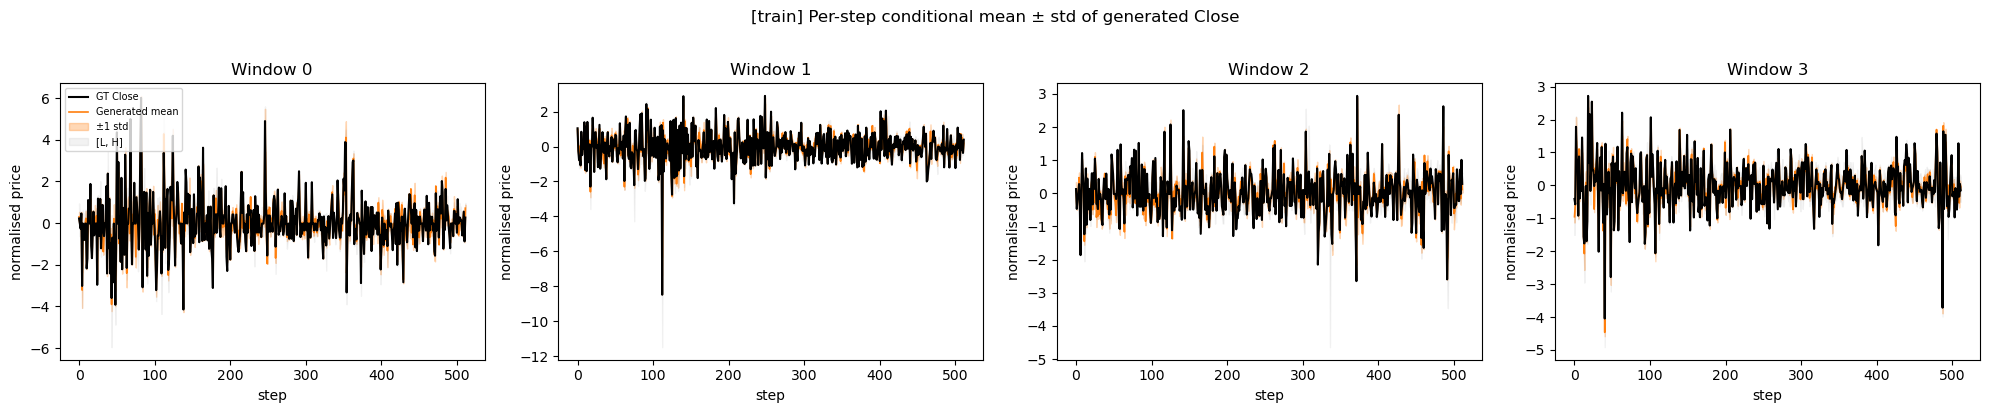

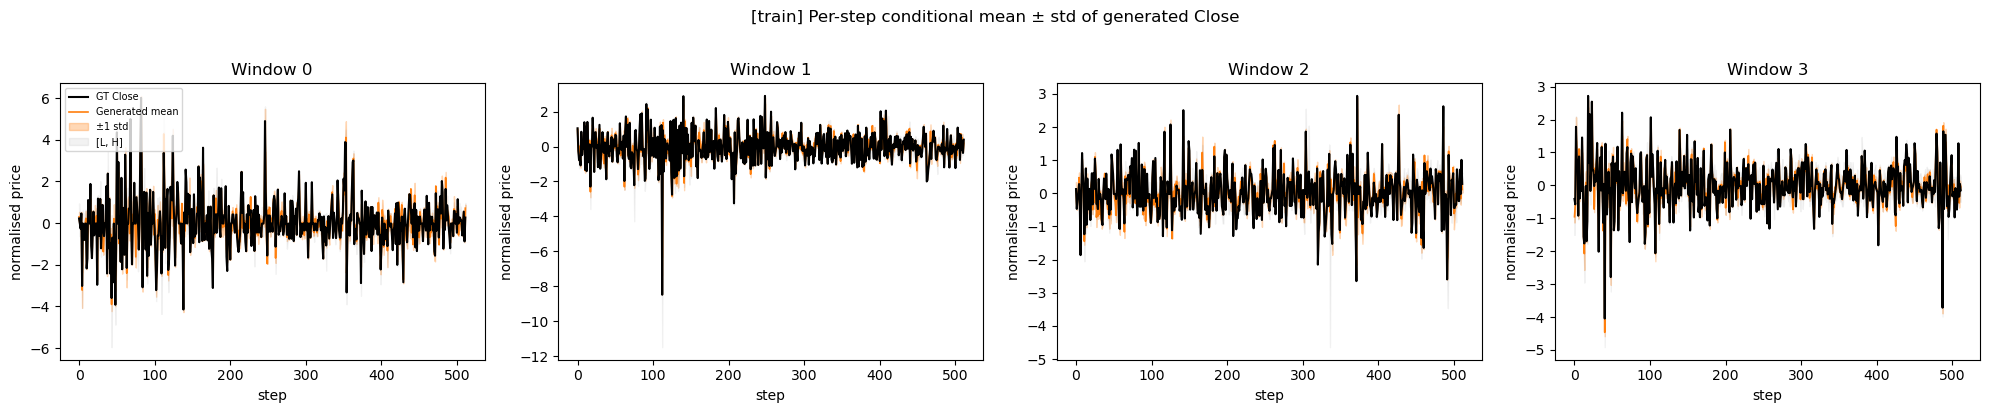

In [ ]:
if compute_graph_overlap:
    for sign, mask_fn, suffix in [(1, lambda x: x > 0, "pos"), (-1, lambda x: x < 0, "neg")]:
        m_gt  = mask_fn(gt_dist_x)
        m_gen = mask_fn(gen_dist_x)
        plt.figure(dpi=150)
        plt.plot(sign * gt_dist_x[m_gt],   gt_dist_y[m_gt],  '.', color="tab:blue",   label="GT")
        plt.plot(sign * gen_dist_x[m_gen],  gen_dist_y[m_gen],'.', color="tab:orange", label="Generated")
        plt.xscale('log'); plt.yscale('log')
        plt.xlabel('Normalized Scale in $\sigma$', fontsize=20)
        plt.ylabel('Probability Density Function $P(r)$', fontsize=20)
        plt.legend(fontsize=14)
        display(fig)
        plt.savefig(str(output_dir / f"overlap_distribution_{CHECKPOINT_STEM}_{suffix}_log_{appendix}.png"), transparent=True)
        plt.close(fig)

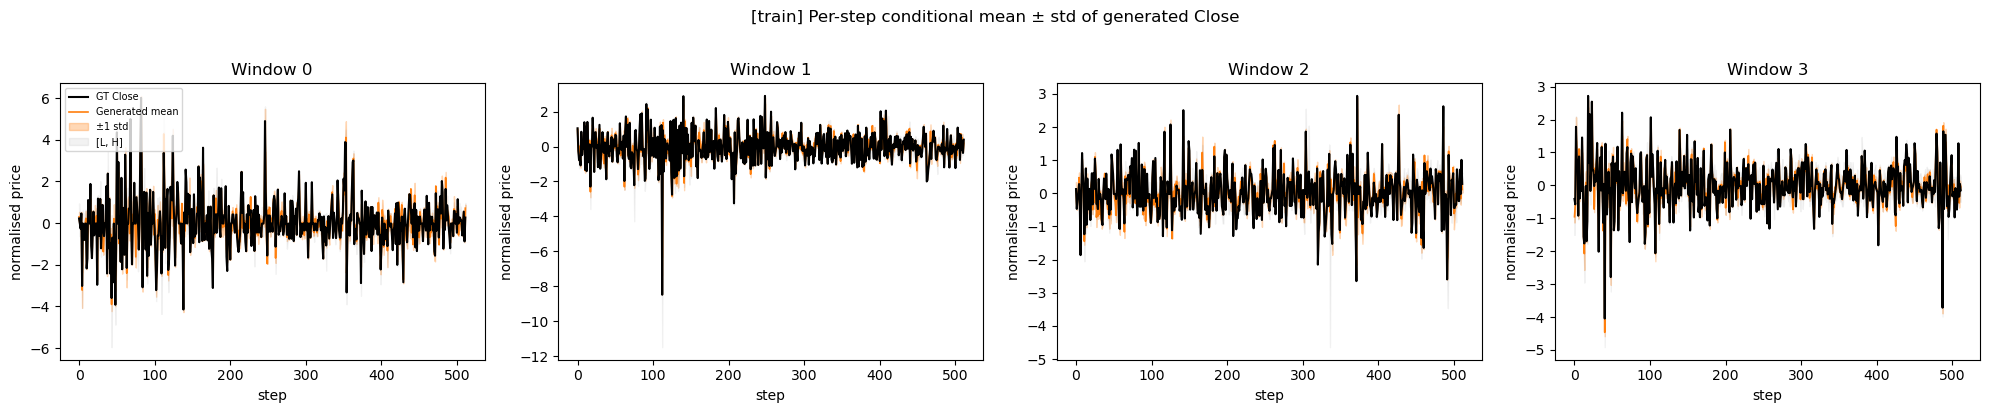

In [ ]:
if compute_graph_overlap:
    lags = np.linspace(1, gt_acf_res.size, gt_acf_res.size)
    plt.figure(dpi=150)
    plt.plot(lags, gt_acf_res,  '.', color="tab:blue",   label="GT")
    plt.plot(lags, gen_acf_res, '.', color="tab:orange", label="Generated")
    plt.ylim(1e-5, 1.)
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel('lag $k$', fontsize=20)
    plt.ylabel('Auto-correlation', fontsize=20)
    plt.legend(fontsize=14)
    display(fig)
    plt.savefig(str(output_dir / f"overlap_volatility_clustering_{CHECKPOINT_STEM}_{appendix}.png"), transparent=True)
    plt.close(fig)


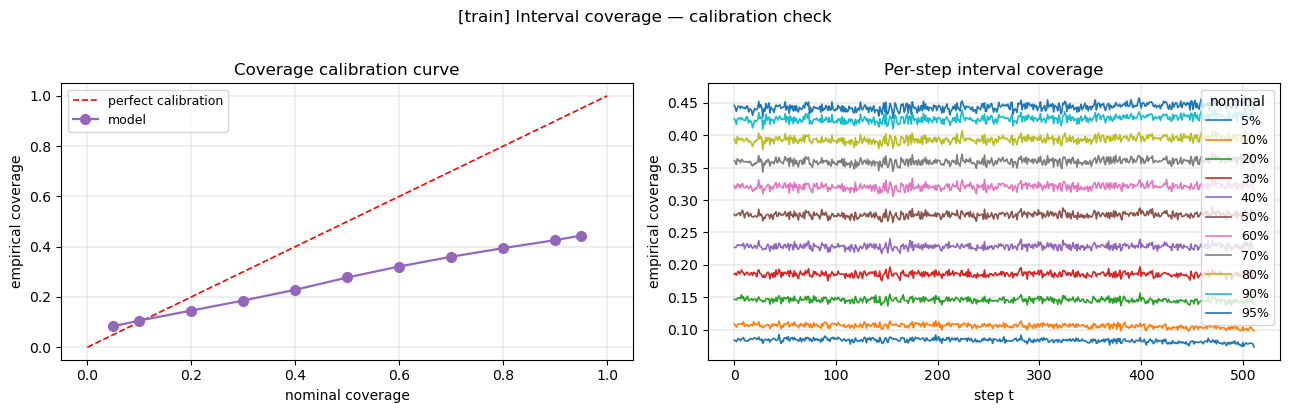

In [ ]:
if compute_graph_overlap:
    plt.figure(dpi=150)
    plt.plot(range(1, min(100, seq_len // 2)), gt_levs,  color="tab:blue",   label="GT")
    plt.plot(range(1, min(100, seq_len // 2)), gen_levs, color="tab:orange", label="Generated")
    plt.axhline()
    plt.xlabel(r'$t$', fontsize=20)
    plt.ylabel(r'$L(t)$', fontsize=20)
    plt.legend(fontsize=14)
    display(fig)
    plt.savefig(str(output_dir / f"overlap_leverage_effect_{CHECKPOINT_STEM}_{appendix}.png"), transparent=True)
    plt.close(fig)


## Interpretation guide

| Test | Passing (overfit / well-conditioned) | Failing |
|------|--------------------------------------|---------|
| **Sample paths** (§3) | Generated Close tracks GT inside [L,H] | Paths wander outside [L,H] or uncorrelated with GT |
| **OHLC constraint** (§4) | Step-wise rate > 0.90 | Rate < 0.5 → model ignores OHL context |
| **Marginal KS** (§5) | KS p > 0.05; QQ on diagonal | S-curve in QQ (wrong tail shape) |
| **Increment KS** (§6) | KS p > 0.05; similar std | Generated std much larger → noise not removed |
| **Level ACF** (§6) | Generated ACF tracks GT shape | Flat or too fast decay → wrong temporal structure |
| **Increment ACF** (§6) | Both near 0 at all lags | Positive lags → spurious momentum |
| **Per-step mean** (§7) | MAE near 0; small residual std | Large MAE → bad conditioning; large std → excess uncertainty |

# Unnormalization of close values

In [19]:
# ── 12.1  Load column-level mean / std ────────────────────────────────────────
stats_df = pd.read_csv(STATS_FILE, header=0, index_col=0)
stats_df.columns = ["mean", "std"]
stats_df.index   = stats_df.index.str.strip().str.lower()

print("Column statistics loaded:")
display(stats_df)

col_stats = stats_df.to_dict(orient="index")
# col_stats["close"] → {"mean": ..., "std": ...}


Column statistics loaded:


,mean,std
close,0.000451,0.020867
open,0.000265,0.010859
high,0.012179,0.019033
low,-0.011306,0.017881


In [20]:
# ── 12.2  Load raw (unnormalized) log-return CSVs ─────────────────────────────
import glob

raw_files = glob.glob(os.path.join(RAW_DATA_FOLDER, "*.csv"))
assert raw_files, f"No CSV files found in {RAW_DATA_FOLDER}"

raw_dfs = []
for fpath in raw_files:
    df = pd.read_csv(fpath, parse_dates=["date"], dayfirst=True)
    df.columns = df.columns.str.strip().str.lower()
    # expected columns: date, open, high, low, close
    df = df.sort_values("date").iloc[1:].reset_index(drop=True)   # drop earliest-date row
    raw_dfs.append(df)

raw_all = pd.concat(raw_dfs, ignore_index=True)

print(f"Loaded {len(raw_files)} files → {len(raw_all):,} rows after dropping first record each")
print(f"Columns  : {list(raw_all.columns)}")
print(f"Date range: {raw_all['date'].min().date()} → {raw_all['date'].max().date()}")
display(raw_all.describe().loc[["mean", "std", "min", "25%", "50%", "75%", "max"]])


# raw_all = raw_all.drop(columns=["adj_close"])

Loaded 354 files → 3,114,666 rows after dropping first record each
Columns  : ['date', 'open', 'high', 'low', 'close', 'adj_close']
Date range: 1962-01-03 → 2026-05-01


,date,open,high,low,close,adj_close
mean,2005-05-03 02:19:58.425771520,52.366296,52.992119,51.730228,52.374868,68.955794
std,NaN,182.516183,184.719706,180.349933,182.541080,131.628668
min,1962-01-03 00:00:00,0.001410,0.001427,0.001385,0.001410,0.194389
25%,1995-04-04 00:00:00,4.140900,4.196000,4.085446,4.141720,4.119557
50%,2007-08-15 00:00:00,17.440939,17.677002,17.192500,17.444148,18.927610
75%,2017-06-21 00:00:00,49.098019,49.645996,48.544115,49.114542,42.992410
max,2026-05-01 00:00:00,9914.169922,9964.769531,9794.000000,9924.400391,688.369995


In [21]:
# ── 12.3  Unnormalize generated Close (and GT arrays) ─────────────────────────
def unnorm(arr, feature):
    mu  = col_stats[feature]["mean"]
    sig = col_stats[feature]["std"]
    return arr * sig + mu

# gen_3d : (n_windows, n_samples, seq_len)  — generated Close, normalized
gen_3d_unnorm   = unnorm(gen_3d,   "close")
gt_close_unnorm = unnorm(gt_close, "close")
if not is_unconditional:
    gt_open_unnorm  = unnorm(gt_open,  "open")
    gt_high_unnorm  = unnorm(gt_high,  "high")
    gt_low_unnorm   = unnorm(gt_low,   "low")
else:
    gt_open_unnorm = gt_high_unnorm = gt_low_unnorm = None

print("Unnormalized shapes:")
print(f"  gen_3d_unnorm   : {gen_3d_unnorm.shape}")
print(f"  gt_close_unnorm : {gt_close_unnorm.shape}")
if not is_unconditional:
    print(f"  gt_open_unnorm  : {gt_open_unnorm.shape}")
    print(f"  gt_high_unnorm  : {gt_high_unnorm.shape}")
    print(f"  gt_low_unnorm   : {gt_low_unnorm.shape}")


Unnormalized shapes:
  gen_3d_unnorm   : (237, 5, 512)
  gt_close_unnorm : (237, 512)


In [22]:
# ── 12.4  Aggregate statistics ────────────────────────────────────────────────
gen_close_flat = gen_3d_unnorm.reshape(-1)
gt_close_flat  = gt_close_unnorm.ravel()

def summary_stats(x, label):
    return {
        "source"          : label,
        "n"               : len(x),
        "mean"            : np.mean(x),
        "std"             : np.std(x),
        "min"             : np.min(x),
        "q01"             : np.quantile(x, 0.01),
        "q05"             : np.quantile(x, 0.05),
        "median"          : np.median(x),
        "q95"             : np.quantile(x, 0.95),
        "q99"             : np.quantile(x, 0.99),
        "max"             : np.max(x),
        "skewness"        : float(scipy_stats.skew(x)),
        "excess_kurtosis" : float(scipy_stats.kurtosis(x, fisher=True)),
    }

df_stats = pd.DataFrame([
    summary_stats(gen_close_flat, "Generated Close (unnorm)"),
    summary_stats(gt_close_flat,  "GT Close — windows (unnorm)"),
]).set_index("source")

print("=" * 70)
print("  AGGREGATE STATISTICS — UNNORMALIZED CLOSE LOG-RETURNS")
print("=" * 70)
display(df_stats.T.style.format("{:.6f}", subset=df_stats.T.columns).format({"n": "{:.0f}"}))

  AGGREGATE STATISTICS — UNNORMALIZED CLOSE LOG-RETURNS


source,Generated Close (unnorm),GT Close — windows (unnorm)
n,606720.000000,121344.000000
mean,0.000515,0.000580
std,0.015261,0.020673
min,-0.669182,-0.735587
q01,-0.040436,-0.050211
q05,-0.022227,-0.026841
median,0.000005,0.000000
q95,0.023678,0.028252
q99,0.042669,0.051767
max,0.297609,2.251889


OHLC price-space constraint skipped — no OHL context in unconditional mode.


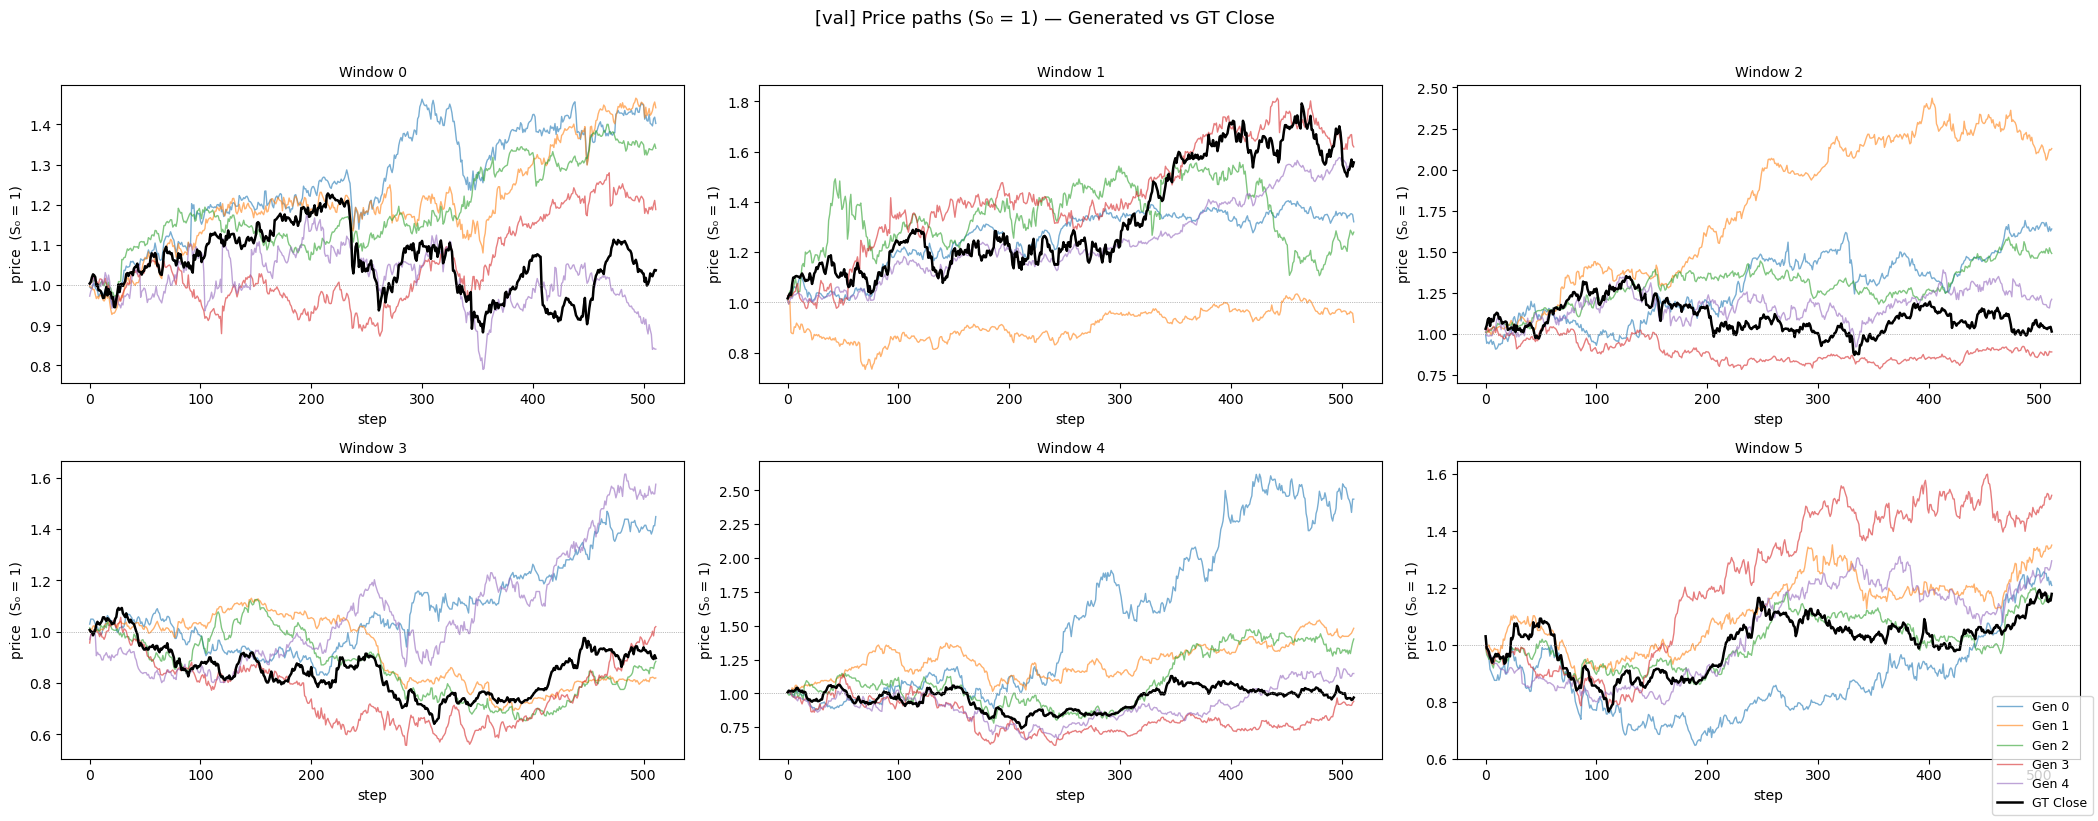

In [23]:
# ── OHLC constraint in price space + price path plots ────────────────────────
# Inputs (from unnormalization section):
#   gen_3d_unnorm   : (n_windows, n_samples, seq_len)  generated Close log-returns
#   gt_close_unnorm : (n_windows, seq_len)             GT Close log-returns
#   gt_open_unnorm  : (n_windows, seq_len)             GT Open  log-returns
#   gt_high_unnorm  : (n_windows, seq_len)             GT High  log-returns
#   gt_low_unnorm   : (n_windows, seq_len)             GT Low   log-returns
#
# Relationship: r_t = log(X_t / C_{t-1})  →  X_t = C_{t-1} * exp(r_t)
# Starting price: S_0 = C_{-1} = 1

import math

N_PRICE_SHOW = min(n_windows, 6)

gt_close_price  = np.cumprod(np.exp(gt_close_unnorm), axis=1)
gen_close_price = np.cumprod(np.exp(gen_3d_unnorm),   axis=2)

if not is_unconditional:
    gt_prev_close = np.concatenate(
        [np.ones((n_windows, 1)), gt_close_price[:, :-1]], axis=1
    )
    gt_open_price = gt_prev_close * np.exp(gt_open_unnorm)
    gt_high_price = gt_prev_close * np.exp(gt_high_unnorm)
    gt_low_price  = gt_prev_close * np.exp(gt_low_unnorm)

    gen_in_band = (
        (gen_close_price >= gt_low_price[:, np.newaxis, :]) &
        (gen_close_price <= gt_high_price[:, np.newaxis, :])
    )
    gt_in_band_p = (
        (gt_close_price >= gt_low_price) &
        (gt_close_price <= gt_high_price)
    )
    gen_step_rate    = gen_in_band.reshape(-1, seq_len).mean(axis=0)
    gen_overall      = float(gen_in_band.mean())
    gen_fully_valid  = float(gen_in_band.all(axis=2).mean())
    gt_step_rate_p   = gt_in_band_p.mean(axis=0)
    gt_overall_p     = float(gt_in_band_p.mean())
    gt_fully_valid_p = float(gt_in_band_p.all(axis=1).mean())

    print("=" * 60)
    print("  OHLC PRICE CONSTRAINT   Low_t ≤ Close_t ≤ High_t")
    print("=" * 60)
    print(f"{'Metric':<38} {'Generated':>10} {'GT (ref)':>10}")
    print("-" * 60)
    print(f"{'Step-wise satisfaction rate':<38} {gen_overall:>10.4f} {gt_overall_p:>10.4f}")
    print(f"{'Fully valid sequences (rate)':<38} {gen_fully_valid:>10.4f} {gt_fully_valid_p:>10.4f}")

    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(steps, gen_step_rate,  color="tab:orange", lw=1.5,
            label=f"Generated  (overall={gen_overall:.3f})")
    ax.plot(steps, gt_step_rate_p, color="tab:blue",   lw=1.5, ls="--",
            label=f"GT (ref)   (overall={gt_overall_p:.3f})")
    ax.axhline(1.0, color="black", lw=0.8, ls=":", label="Perfect (1.0)")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("step t")
    ax.set_ylabel("fraction  Low_t ≤ Close_t ≤ High_t")
    ax.set_title(f"[{ANALYSIS_SPLIT}] OHLC price-space constraint per step — Generated vs GT")
    ax.legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)
else:
    print("OHLC price-space constraint skipped — no OHL context in unconditional mode.")

# ── Price path plots ─────────────────────────────────────────────────────────
n_cols = min(3, N_PRICE_SHOW)
n_rows = math.ceil(N_PRICE_SHOW / n_cols)
GEN_COLORS = [plt.cm.tab10(i) for i in range(n_samples)]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for col, w in enumerate(range(N_PRICE_SHOW)):
    ax = axes_flat[col]
    for s in range(n_samples):
        ax.plot(steps, gen_close_price[w, s], color=GEN_COLORS[s], lw=1.0, alpha=0.6,
                label=f"Gen {s}" if col == 0 else None)
    ax.plot(steps, gt_close_price[w], color="black", lw=1.8,
            label="GT Close" if col == 0 else None)
    ax.axhline(1.0, color="gray", lw=0.5, ls=":")
    ax.set_title(f"Window {window_ids[w]}", fontsize=10)
    ax.set_xlabel("step")
    ax.set_ylabel("price  (S₀ = 1)")

for ax in axes_flat[N_PRICE_SHOW:]:
    ax.set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=9)
plt.suptitle(f"[{ANALYSIS_SPLIT}] Price paths (S₀ = 1) — Generated vs GT Close",
             y=1.01, fontsize=13)
plt.tight_layout()
display(fig)
plt.close(fig)


In [38]:
SELECTED_KEYS = [('ABT_1980-03-17_2026-04-10.csv', 8700), ('ADI_1980-03-17_2026-04-10.csv', 7400), ('AEP_1962-01-02_2026-04-10.csv', 1800), ('AEP_1962-01-02_2026-04-10.csv', 1900), ('AEP_1962-01-02_2026-04-10.csv', 2000), ('AFL_1980-03-17_2026-04-10.csv', 7900), ('AIG_1973-01-02_2026-04-10.csv', 3000), ('AIG_1973-01-02_2026-04-10.csv', 3100), ('AMAT_1980-03-17_2026-04-10.csv', 6100), ('AMD_1980-03-17_2026-04-10.csv', 10800), ('APD_1980-03-17_2026-04-10.csv', 1900), ('ATO_1983-12-28_2026-04-10.csv', 8600), ('AVY_1973-02-21_2026-04-10.csv', 6100), ('BAC_1973-02-21_2026-04-10.csv', 5100), ('BALL_1973-02-21_2026-04-10.csv', 2800), ('BA_1962-01-02_2026-04-10.csv', 12200), ('BA_1962-01-02_2026-04-10.csv', 12300), ('BA_1962-01-02_2026-04-10.csv', 12400)]

df_ohlc_B = data[ANALYSIS_SPLIT][1]
key_lookup_B = df_ohlc_B.drop_duplicates("window_idx").set_index(["file", "window_start"])["window_idx"]

matched_window_ids = []
for key in SELECTED_KEYS:
    if key in key_lookup_B.index:
        matched_window_ids.append(int(key_lookup_B.loc[key]))
    else:
        print(f"Warning: window {key} not found in split '{ANALYSIS_SPLIT}' — skipping")

show_positions = [window_ids.index(wid) for wid in matched_window_ids]
N_PRICE_SHOW   = len(show_positions)


Column 0 window position 0 window ID 0
Column 1 window position 1 window ID 1
Column 2 window position 3 window ID 3
Column 3 window position 4 window ID 4
Column 4 window position 5 window ID 5
Column 5 window position 6 window ID 6
Column 6 window position 7 window ID 7
Column 7 window position 8 window ID 8
Column 8 window position 9 window ID 9
Column 9 window position 10 window ID 10
Column 10 window position 11 window ID 11
Column 11 window position 12 window ID 12
Column 12 window position 13 window ID 13
Column 13 window position 15 window ID 15
Column 14 window position 16 window ID 16
Column 15 window position 17 window ID 17
Column 16 window position 18 window ID 18
Column 17 window position 19 window ID 19


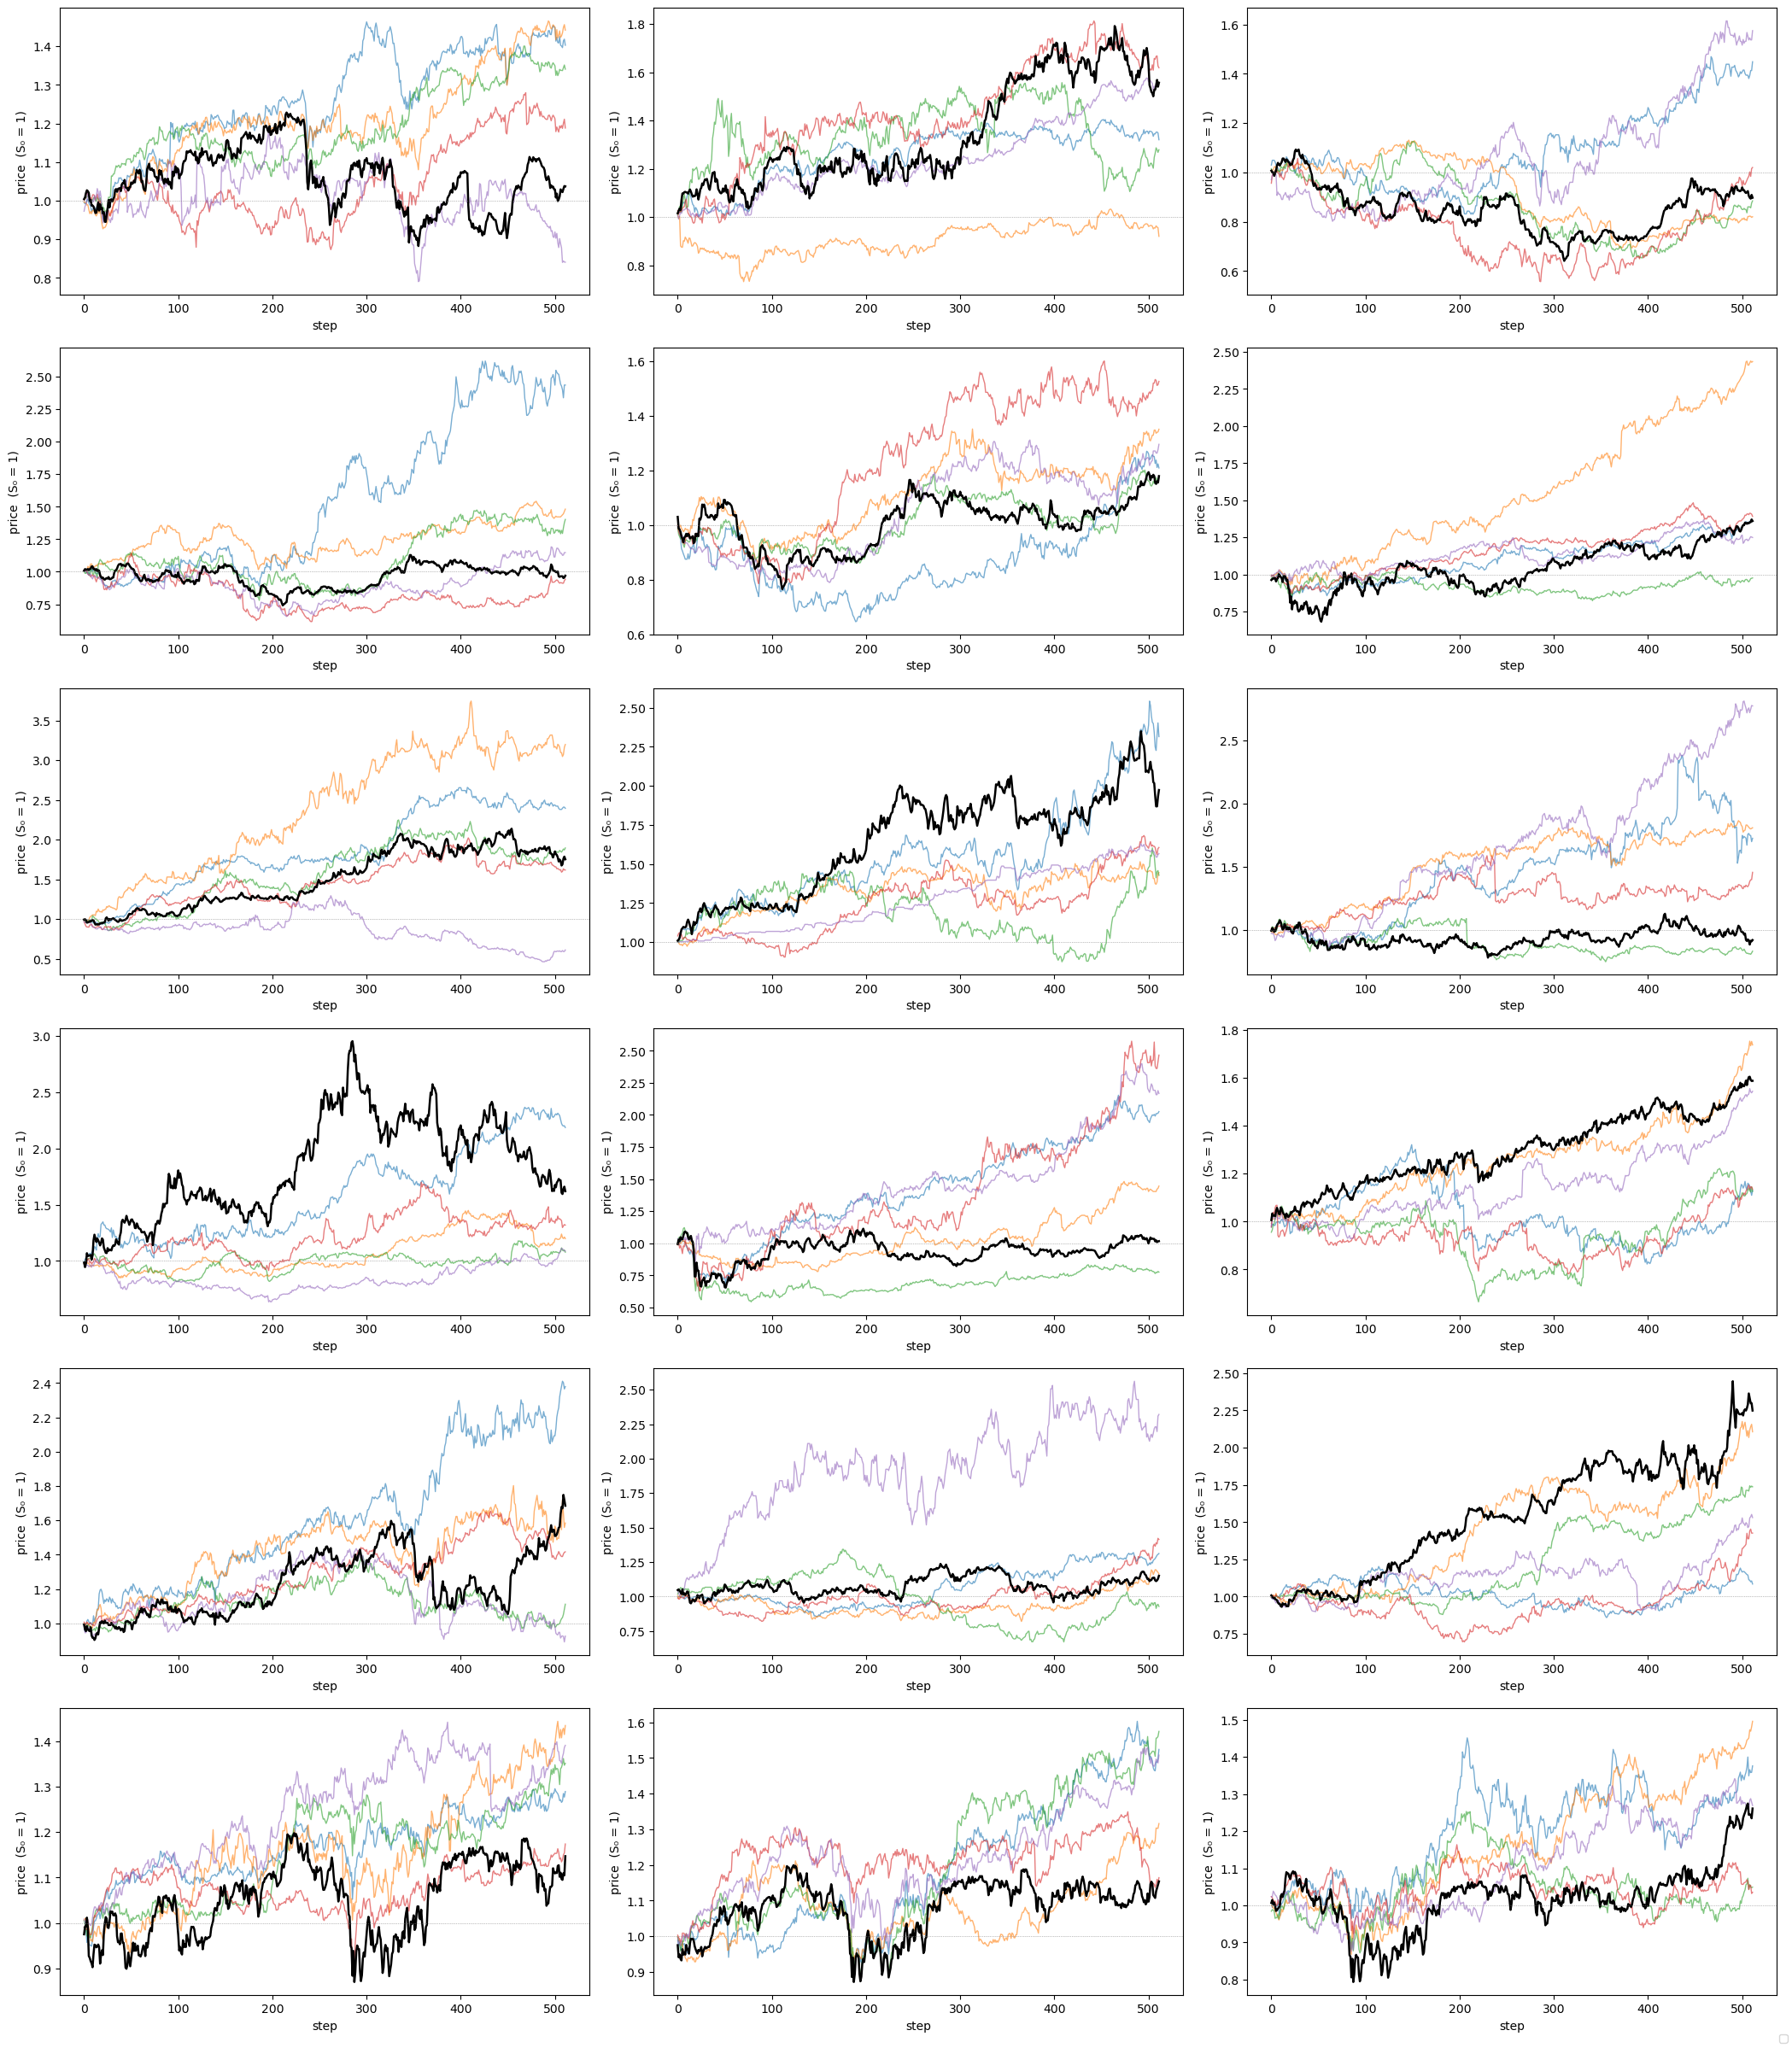

In [39]:
# ── 3. Price path plots: GT Close + generated Close, all starting from S₀ = 1 ─
# SELECT_INDICES = True
# # SELECTED_WINDOW_IDS = [0, 1, 3, 4, 5, 11, 15, 19, 150, 200, 60, 70, 80, 90, 110]  # actual window_idx values you want to inspect 10
# SELECTED_WINDOW_IDS = [3, 99, 5, 70, 150, 67]  # actual window_idx values you want to inspect 10


# if SELECT_INDICES:
#     show_positions = [window_ids.index(wid) for wid in SELECTED_WINDOW_IDS]
# else:
#     show_positions = list(range(min(n_windows, 6)))

# N_PRICE_SHOW = len(show_positions)


n_cols = min(3, N_PRICE_SHOW)
n_rows = math.ceil(N_PRICE_SHOW / n_cols)
GEN_COLORS = [plt.cm.tab10(i) for i in range(n_samples)]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for col, w in enumerate(show_positions):
    print("Column", col, "window position", w, "window ID", window_ids[w])
    ax = axes_flat[col]
    for s in range(n_samples):
        ax.plot(
            steps, gen_close_price[w, s],
            color=GEN_COLORS[s], lw=1.0, alpha=0.6,
            # label=f"Gen {s}" if col == 0 else None,
        )
    ax.plot(
        steps, gt_close_price[w],
        color="black", lw=1.8,
        # label="GT Close" if col == 0 else None,
    )
    ax.axhline(1.0, color="gray", lw=0.5, ls=":")
    # ax.set_title(f"Window {window_ids[w]}", fontsize=10)
    ax.set_xlabel("step")
    ax.set_ylabel("price  (S₀ = 1)")

for ax in axes_flat[N_PRICE_SHOW:]:
    ax.set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=9)

# plt.suptitle(
#     f"[{ANALYSIS_SPLIT}] Price paths (S₀ = 1) — Generated vs GT Close",
#     y=1.01, fontsize=13,    
# )
plt.tight_layout()
display(fig)
plt.close(fig)

# Additional window-conditional analysis metrics

## 10. CRPS — probabilistic forecast quality

**CRPS** (Continuous Ranked Probability Score) evaluates the full predictive distribution, not just the posterior mean:

$$\text{CRPS}(\hat{F}, y) = \mathbb{E}[|X - y|] - \tfrac{1}{2}\,\mathbb{E}[|X - X'|]$$

where $X, X'$ are independent draws from the ensemble. Lower is better.  
A perfect *point* forecast collapses to MAE, so CRPS ≤ MAE always — the gap measures how much the spread helps beyond the mean prediction.

Mean CRPS : 0.16431
Mean MAE  : 0.21045   (CRPS of a perfect point forecast = MAE)
Spread skill gap  (MAE − CRPS) : 0.04614  (positive → spread helps)

Mean Term1  E[|X - y|]   : 0.24922   (accuracy penalty)
Mean Term2  E[|X - X'|]  : 0.16982   (spread reward × 2)
  → CRPS = Term1 − 0.5×Term2 = 0.24922 − 0.08491 = 0.16431



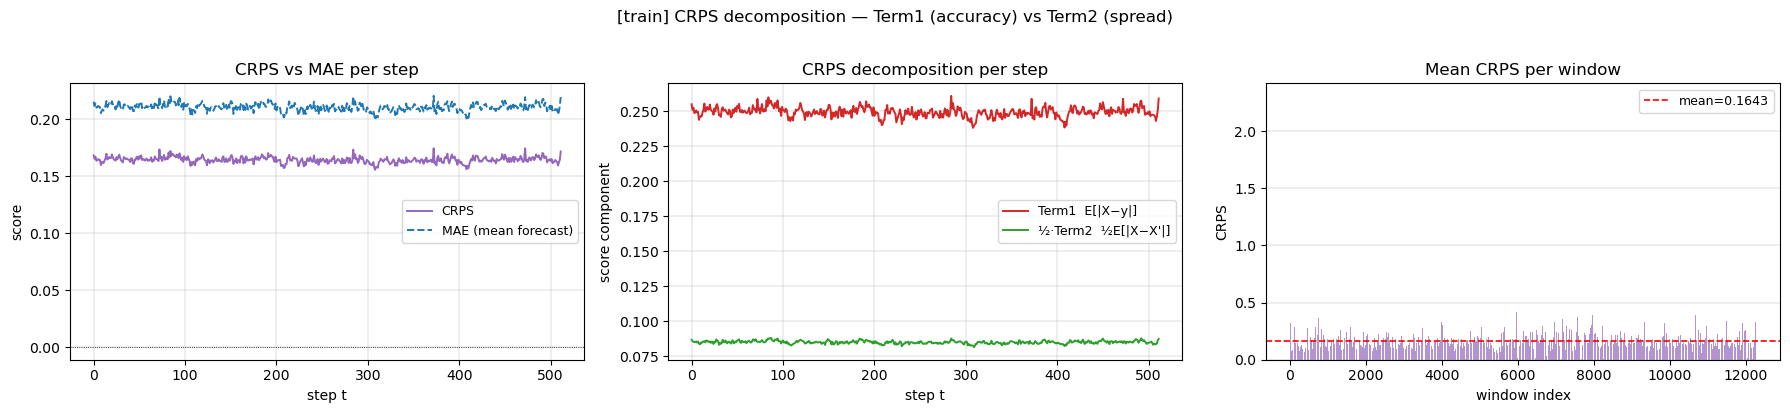

In [ ]:
def crps_ensemble_batch(samples, obs):
    """
    CRPS for every (window, step) position.

    Parameters
    ----------
    samples : (n_windows, n_samples, seq_len)
    obs     : (n_windows, seq_len)

    Returns
    -------
    crps  : (n_windows, seq_len)
    term1 : (n_windows, seq_len)  — E[|X - y|]
    term2 : (n_windows, seq_len)  — E[|X - X'|]
    """
    term1 = np.mean(np.abs(samples - obs[:, np.newaxis, :]), axis=1)

    n_windows_loc = samples.shape[0]
    term2 = np.zeros_like(term1)
    for w in range(n_windows_loc):
        s = samples[w]
        diff = np.abs(s[:, np.newaxis, :] - s[np.newaxis, :, :])
        term2[w] = diff.mean(axis=(0, 1))

    return term1 - 0.5 * term2, term1, term2

crps_grid, term1_grid, term2_grid = crps_ensemble_batch(gen_3d, gt_close)
mean_crps = float(crps_grid.mean())
mean_mae  = float(np.abs(gen_3d.mean(axis=1) - gt_close).mean())

print(f"Mean CRPS : {mean_crps:.5f}")
print(f"Mean MAE  : {mean_mae:.5f}   (CRPS of a perfect point forecast = MAE)")
print(f"Spread skill gap  (MAE − CRPS) : {mean_mae - mean_crps:.5f}  "
      f"({'positive → spread helps' if mean_mae > mean_crps else 'negative → spread hurts'})")
print()
print(f"Mean Term1  E[|X - y|]   : {term1_grid.mean():.5f}   (accuracy penalty)")
print(f"Mean Term2  E[|X - X'|]  : {term2_grid.mean():.5f}   (spread reward × 2)")
print(f"  → CRPS = Term1 − 0.5×Term2 = {term1_grid.mean():.5f} − {0.5*term2_grid.mean():.5f} = {mean_crps:.5f}")
print()

crps_per_step  = crps_grid.mean(axis=0)
term1_per_step = term1_grid.mean(axis=0)
term2_per_step = term2_grid.mean(axis=0)
mae_per_step   = np.abs(gen_3d.mean(axis=1) - gt_close).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(steps, crps_per_step,  color="tab:purple", lw=1.4, label="CRPS")
axes[0].plot(steps, mae_per_step,   color="tab:blue",   lw=1.4, label="MAE (mean forecast)", ls="--")
axes[0].axhline(0, color="black", lw=0.6, ls=":")
axes[0].set_title("CRPS vs MAE per step")
axes[0].set_xlabel("step t"); axes[0].set_ylabel("score")
axes[0].legend(fontsize=9); axes[0].grid(True, linewidth=0.3)

axes[1].plot(steps, term1_per_step,         color="tab:red",    lw=1.4, label="Term1  E[|X−y|]")
axes[1].plot(steps, 0.5 * term2_per_step,   color="tab:green",  lw=1.4, label="½·Term2  ½E[|X−X'|]")
axes[1].set_title("CRPS decomposition per step")
axes[1].set_xlabel("step t"); axes[1].set_ylabel("score component")
axes[1].legend(fontsize=9); axes[1].grid(True, linewidth=0.3)

crps_per_window = crps_grid.mean(axis=1)
axes[2].bar(np.arange(n_windows), crps_per_window, color="tab:purple", alpha=0.7)
axes[2].axhline(mean_crps, color="red", lw=1.2, ls="--", label=f"mean={mean_crps:.4f}")
axes[2].set_title("Mean CRPS per window")
axes[2].set_xlabel("window index"); axes[2].set_ylabel("CRPS")
axes[2].legend(fontsize=9); axes[2].grid(axis="y", linewidth=0.3)

plt.suptitle(f"[{ANALYSIS_SPLIT}] CRPS decomposition — Term1 (accuracy) vs Term2 (spread)", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/conditional/crps_dec_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)


## 11. Interval coverage — calibration check

For each nominal level $1-\alpha$ the empirical interval is $[q_{\alpha/2},\, q_{1-\alpha/2}]$ of the ensemble, computed per (window, step).

- **Empirical ≈ nominal** → well-calibrated uncertainty.  
- **Empirical < nominal** → overconfident (intervals too narrow).  
- **Empirical > nominal** → underconfident (intervals too wide).

Interval coverage  (empirical ≈ nominal → well-calibrated)
  gap > 0 → underconfident   |   gap < 0 → overconfident



,empirical,mean width,gap
nominal,,,
0.050000,0.0832,0.01910,+0.0332
0.100000,0.1058,0.03821,+0.0058
0.200000,0.1457,0.07642,-0.0543
0.300000,0.1856,0.11463,-0.1144
0.400000,0.2284,0.15284,-0.1716
0.500000,0.2773,0.19105,-0.2227
0.600000,0.3210,0.22926,-0.2790
0.700000,0.3598,0.26747,-0.3402
0.800000,0.3940,0.30568,-0.4060


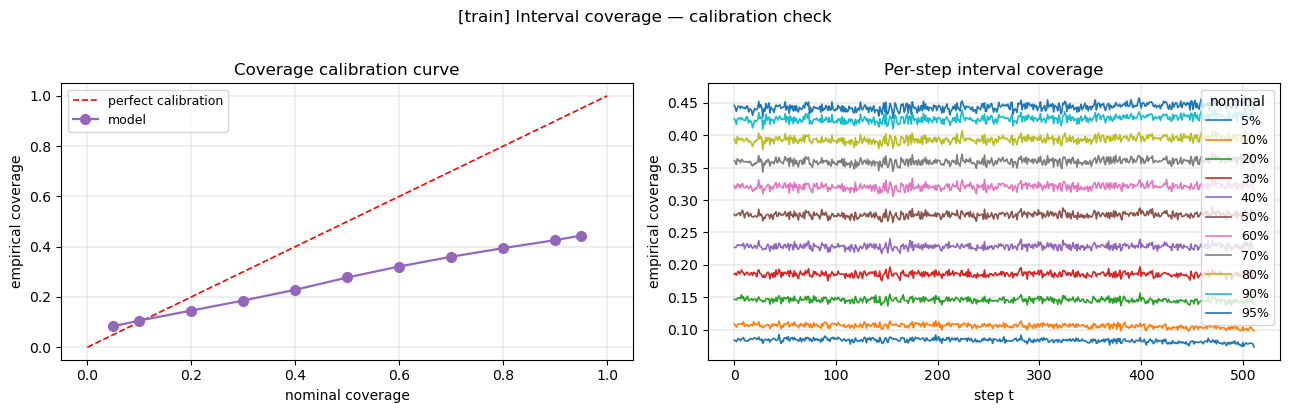

In [ ]:
COVERAGE_LEVELS = [0.05,0.1,0.2,0.3,0.4,0.50,0.6,0.7,0.8,0.90, 0.95]

rows = []
per_step_curves = {}

for level in COVERAGE_LEVELS:
    alpha = 1 - level
    # Empirical quantiles of the ensemble per (window, step)
    lo = np.quantile(gen_3d, alpha / 2,       axis=1)   # (n_windows, seq_len)
    hi = np.quantile(gen_3d, 1 - alpha / 2,   axis=1)   # (n_windows, seq_len)

    in_band          = (gt_close >= lo) & (gt_close <= hi)
    empirical        = float(in_band.mean())
    mean_width       = float((hi - lo).mean())
    per_step_curves[level] = in_band.mean(axis=0)        # (seq_len,) for the plot

    rows.append({
        "nominal"    : level,
        "empirical"  : round(empirical, 4),
        "mean width" : round(mean_width, 5),
        "gap"        : round(empirical - level, 4),
    })

df_cov = pd.DataFrame(rows)
print("Interval coverage  (empirical ≈ nominal → well-calibrated)")
print("  gap > 0 → underconfident   |   gap < 0 → overconfident\n")
display(df_cov.set_index("nominal").style.format(
    {"empirical": "{:.4f}", "mean width": "{:.5f}", "gap": "{:+.4f}"}
))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Calibration curve ─────────────────────────────────────────────────────────
nominals   = [r["nominal"]   for r in rows]
empiricals = [r["empirical"] for r in rows]
axes[0].plot([0, 1], [0, 1], "r--", lw=1.2, label="perfect calibration")
axes[0].plot(nominals, empiricals, "o-", color="tab:purple", lw=1.6, ms=7, label="model")
axes[0].set_xlabel("nominal coverage"); axes[0].set_ylabel("empirical coverage")
axes[0].set_title("Coverage calibration curve")
axes[0].legend(fontsize=9); axes[0].grid(True, linewidth=0.3)

# ── Per-step coverage for each level ─────────────────────────────────────────
for level, curve in per_step_curves.items():
    axes[1].plot(steps, curve, lw=1.2, label=f"{level:.0%}")
axes[1].set_xlabel("step t"); axes[1].set_ylabel("empirical coverage")
axes[1].set_title("Per-step interval coverage")
axes[1].legend(fontsize=9, title="nominal"); axes[1].grid(True, linewidth=0.3)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Interval coverage — calibration check", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/conditional/int_cov_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# plt.show()

# KS and W1 test

In [ ]:
import json

rng = np.random.default_rng(42)

# ── Normalized (subsampled) — gen_paths_arr >> gt_close_pooled by factor n_samples
if len(gen_paths_arr) > len(gt_close_pooled):
    gen_sub     = rng.choice(gen_paths_arr, size=len(gt_close_pooled), replace=False)
    ks_stat, ks_p = scipy_stats.ks_2samp(gen_sub, gt_close_pooled)
    w1_norm_sub   = scipy_stats.wasserstein_distance(gen_sub, gt_close_pooled)
    print(f"Total observations (norm): {len(gt_close_pooled)}")
else:
    ref_sub     = rng.choice(gt_close_pooled, size=len(gen_paths_arr), replace=False)
    ks_stat, ks_p = scipy_stats.ks_2samp(gen_paths_arr, ref_sub)
    w1_norm_sub   = scipy_stats.wasserstein_distance(gen_paths_arr, ref_sub)
    print(f"Total observations (norm): {len(gen_paths_arr)}")
print(f"KS statistic SUBSAMPLED       = {ks_stat:.4f}  |  p-value = {ks_p:.4e}")
print(f"Wasserstein-1 SUBSAMPLED      = {w1_norm_sub:.6f}")

# ── Unnormalized (subsampled) ─────────────────────────────────────────────────
if len(gen_close_flat) > len(gt_close_flat):
    gen_sub_un    = rng.choice(gen_close_flat, size=len(gt_close_flat), replace=False)
    ks_un, ks_p_un = scipy_stats.ks_2samp(gen_sub_un, gt_close_flat)
    w1_un          = scipy_stats.wasserstein_distance(gen_sub_un, gt_close_flat)
    print(f"Total observations (unnorm): {len(gt_close_flat)}")
elif len(gt_close_flat) > len(gen_close_flat):
    ref_sub_un    = rng.choice(gt_close_flat, size=len(gen_close_flat), replace=False)
    ks_un, ks_p_un = scipy_stats.ks_2samp(gen_close_flat, ref_sub_un)
    w1_un          = scipy_stats.wasserstein_distance(gen_close_flat, ref_sub_un)
    print(f"Total observations (unnorm): {len(gen_close_flat)}")
else:
    ks_un, ks_p_un = scipy_stats.ks_2samp(gen_close_flat, gt_close_flat)
    w1_un          = scipy_stats.wasserstein_distance(gen_close_flat, gt_close_flat)
    print(f"Total observations (unnorm): {len(gen_close_flat)}")
print(f"KS statistic SUBSAMPLED (unnorm) = {ks_un:.4f}  |  p-value = {ks_p_un:.4e}")
print(f"Wasserstein-1 SUBSAMPLED (unnorm)= {w1_un:.8f}")

# ── Save metrics ──────────────────────────────────────────────────────────────
metrics = {
    "ks_stat_norm":   float(ks_stat),
    "ks_p_norm":      float(ks_p),
    "w1_norm":        float(w1_norm_sub),
    "ks_stat_unnorm": float(ks_un),
    "ks_p_unnorm":    float(ks_p_un),
    "w1_unnorm":      float(w1_un),
}

out_path = output_dir.parent / f"metrics_ks_w1_{appendix}.json"
with open(out_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved → {out_path}")


Total observations (norm): 10240000
KS statistic SUBSAMPLED       = 0.0418  |  p-value = 0.0000e+00
Wasserstein-1 SUBSAMPLED      = 0.137177
Total observations (unnorm): 10240000
KS statistic SUBSAMPLED (unnorm) = 0.0422  |  p-value = 0.0000e+00
Wasserstein-1 SUBSAMPLED (unnorm)= 0.00286519
Saved → ..\images\final\edm\metrics_ks_w1_repl_UNCO_both_Ps18_smax_PROVA.json


: 